<a href="https://www.kaggle.com/code/omborse771924/llm-generative-ai-usage-analytics-dataset-eda?scriptVersionId=335484609" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mirzayasirabdullah07/llm-and-generative-ai-usage-analytics-dataset/genai_llm_usage_dataset_1000.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/mirzayasirabdullah07/llm-and-generative-ai-usage-analytics-dataset/genai_llm_usage_dataset_1000.csv')

In [3]:
df.head()

,session_id,model_name,application_domain,task_type,prompt_length,total_tokens,temperature,top_p,rag_enabled,latency_sec,hallucination_flag,user_satisfaction,estimated_cost_usd,successful_response
0,1,GPT-4o,Healthcare,Summarization,1319,2455,0.17,0.87,0,3.76,0,4,0.0236,1
1,2,GPT-4o,Customer Support,Summarization,486,1425,0.76,0.51,0,2.36,1,5,0.0236,0
2,3,Gemma 3,Retail,Classification,1439,1648,0.63,0.64,0,3.68,1,4,0.0139,0
3,4,Gemma 3,Retail,Summarization,1662,2812,0.07,0.73,0,3.25,1,4,0.0374,0
4,5,Gemma 3,Finance,Classification,1452,1678,0.10,0.83,0,8.04,0,4,0.0171,0


In [4]:
df.tail()

,session_id,model_name,application_domain,task_type,prompt_length,total_tokens,temperature,top_p,rag_enabled,latency_sec,hallucination_flag,user_satisfaction,estimated_cost_usd,successful_response
995,996,Llama 3.1,Retail,QA,696,1044,1.46,0.95,0,3.99,1,4,0.0076,0
996,997,Qwen 2.5,Finance,RAG,227,1022,0.91,0.90,0,4.47,1,5,0.0026,0
997,998,Claude 3.7,Customer Support,QA,1571,2694,1.50,0.54,1,2.77,0,5,0.0465,1
998,999,Llama 3.1,Customer Support,Classification,1253,2451,0.71,0.76,0,5.21,1,4,0.0157,0
999,1000,Claude 3.7,Healthcare,Classification,482,1341,0.68,0.87,1,1.70,0,5,0.0112,1


In [5]:
df.info

<bound method DataFrame.info of      session_id  model_name application_domain       task_type  prompt_length  \
0             1      GPT-4o         Healthcare   Summarization           1319   
1             2      GPT-4o   Customer Support   Summarization            486   
2             3     Gemma 3             Retail  Classification           1439   
3             4     Gemma 3             Retail   Summarization           1662   
4             5     Gemma 3            Finance  Classification           1452   
..          ...         ...                ...             ...            ...   
995         996   Llama 3.1             Retail              QA            696   
996         997    Qwen 2.5            Finance             RAG            227   
997         998  Claude 3.7   Customer Support              QA           1571   
998         999   Llama 3.1   Customer Support  Classification           1253   
999        1000  Claude 3.7         Healthcare  Classification            482

In [6]:
df.describe

<bound method NDFrame.describe of      session_id  model_name application_domain       task_type  prompt_length  \
0             1      GPT-4o         Healthcare   Summarization           1319   
1             2      GPT-4o   Customer Support   Summarization            486   
2             3     Gemma 3             Retail  Classification           1439   
3             4     Gemma 3             Retail   Summarization           1662   
4             5     Gemma 3            Finance  Classification           1452   
..          ...         ...                ...             ...            ...   
995         996   Llama 3.1             Retail              QA            696   
996         997    Qwen 2.5            Finance             RAG            227   
997         998  Claude 3.7   Customer Support              QA           1571   
998         999   Llama 3.1   Customer Support  Classification           1253   
999        1000  Claude 3.7         Healthcare  Classification            4

In [7]:
df.isnull()

,session_id,model_name,application_domain,task_type,prompt_length,total_tokens,temperature,top_p,rag_enabled,latency_sec,hallucination_flag,user_satisfaction,estimated_cost_usd,successful_response
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

session_id             0
model_name             0
application_domain     0
task_type              0
prompt_length          0
total_tokens           0
temperature            0
top_p                  0
rag_enabled            0
latency_sec            0
hallucination_flag     0
user_satisfaction      0
estimated_cost_usd     0
successful_response    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['session_id', 'model_name', 'application_domain', 'task_type',
       'prompt_length', 'total_tokens', 'temperature', 'top_p', 'rag_enabled',
       'latency_sec', 'hallucination_flag', 'user_satisfaction',
       'estimated_cost_usd', 'successful_response'],
      dtype='object')

## EDA

DATASET SHAPE
(1000, 14)


FIRST 5 ROWS
   session_id model_name application_domain       task_type  prompt_length  \
0           1     GPT-4o         Healthcare   Summarization           1319   
1           2     GPT-4o   Customer Support   Summarization            486   
2           3    Gemma 3             Retail  Classification           1439   
3           4    Gemma 3             Retail   Summarization           1662   
4           5    Gemma 3            Finance  Classification           1452   

   total_tokens  temperature  top_p  rag_enabled  latency_sec  \
0          2455         0.17   0.87            0         3.76   
1          1425         0.76   0.51            0         2.36   
2          1648         0.63   0.64            0         3.68   
3          2812         0.07   0.73            0         3.25   
4          1678         0.10   0.83            0         8.04   

   hallucination_flag  user_satisfaction  estimated_cost_usd  \
0                   0               

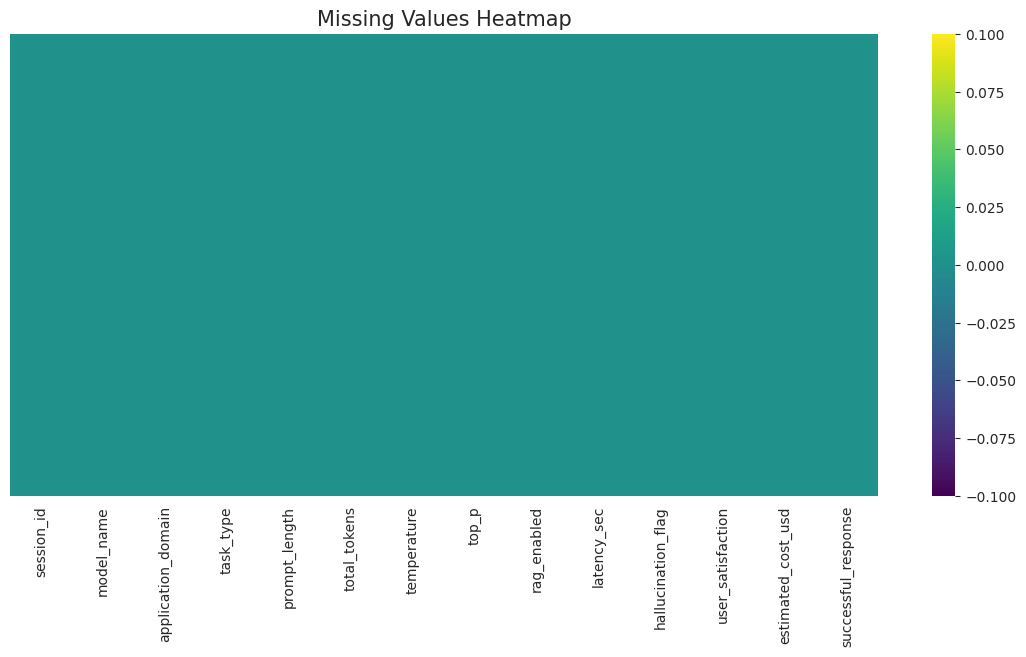

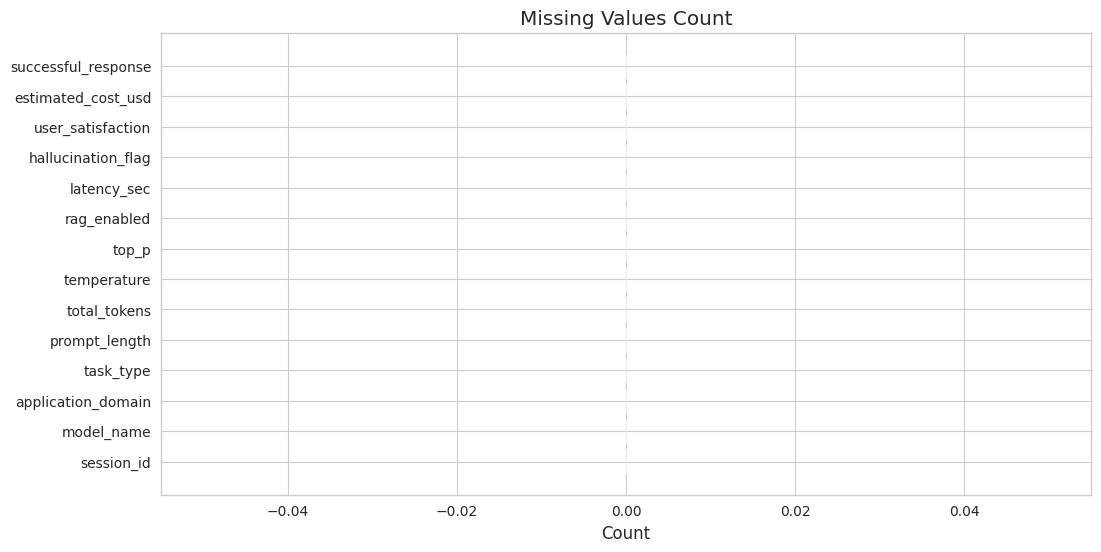



DUPLICATE VALUES
Duplicate Rows : 0


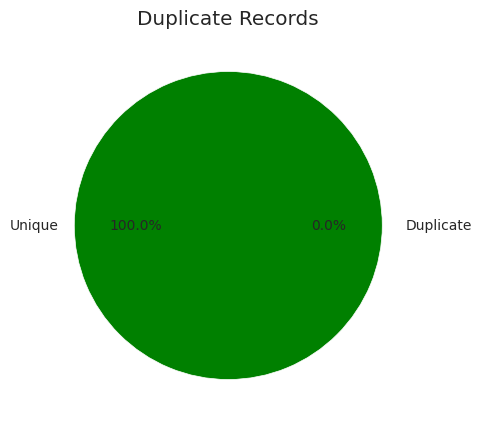



NUMERICAL COLUMNS
['session_id', 'prompt_length', 'total_tokens', 'temperature', 'top_p', 'rag_enabled', 'latency_sec', 'hallucination_flag', 'user_satisfaction', 'estimated_cost_usd', 'successful_response']


CATEGORICAL COLUMNS
['model_name', 'application_domain', 'task_type']


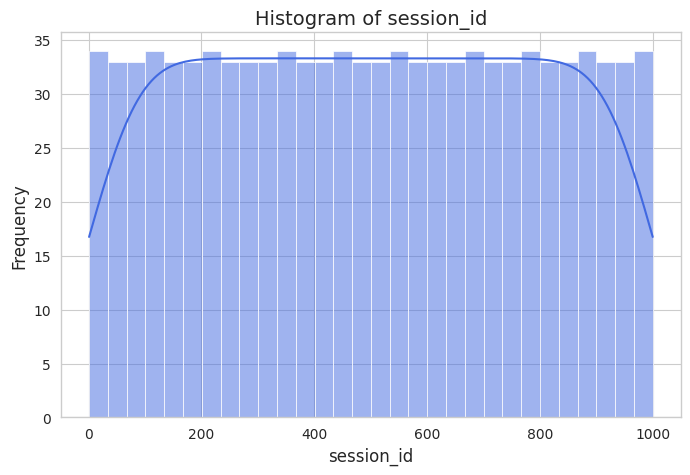

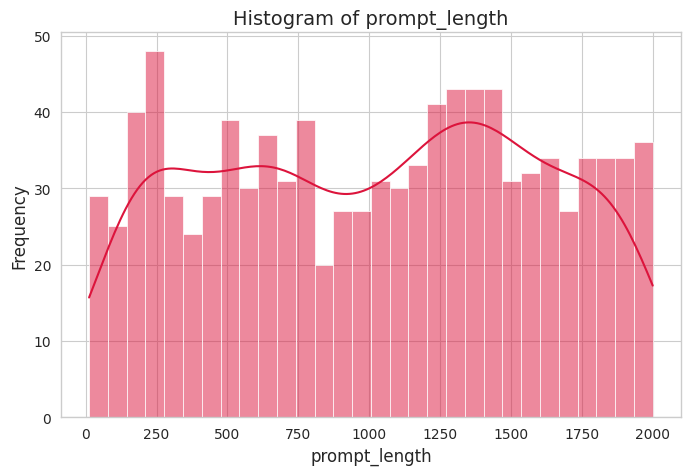

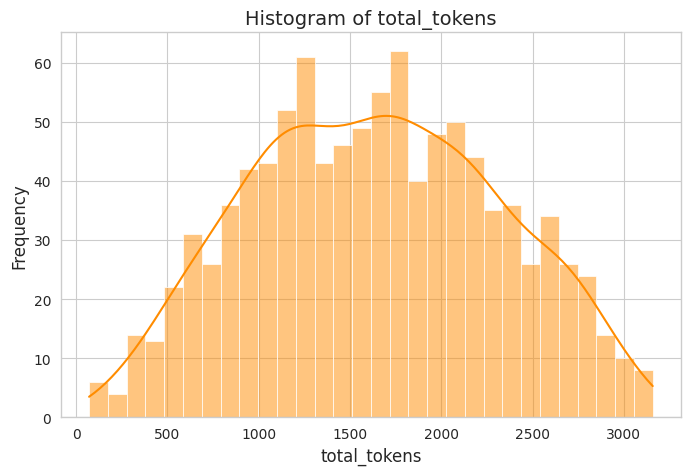

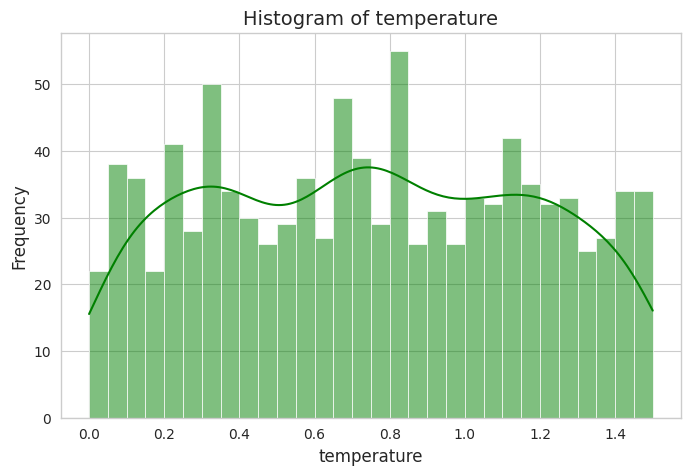

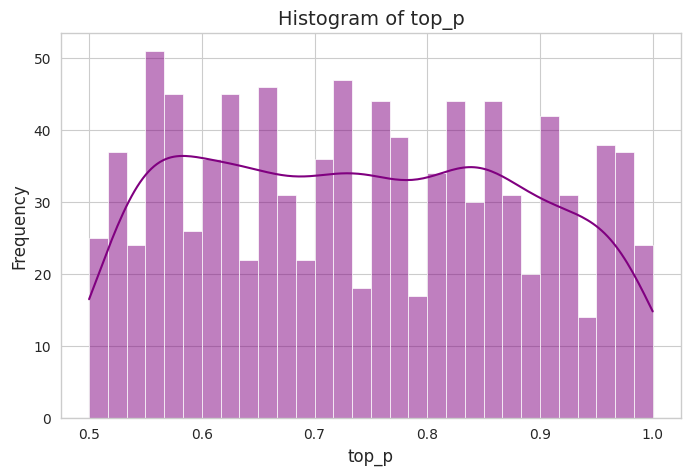

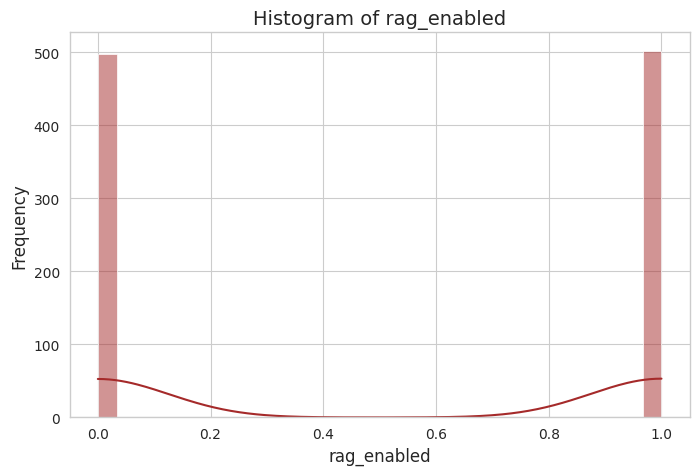

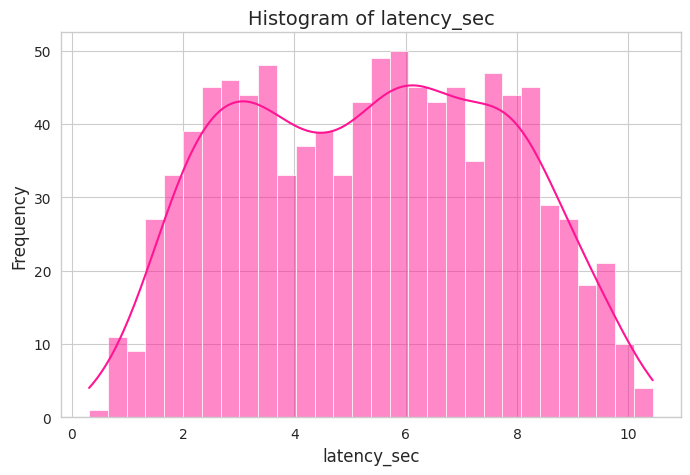

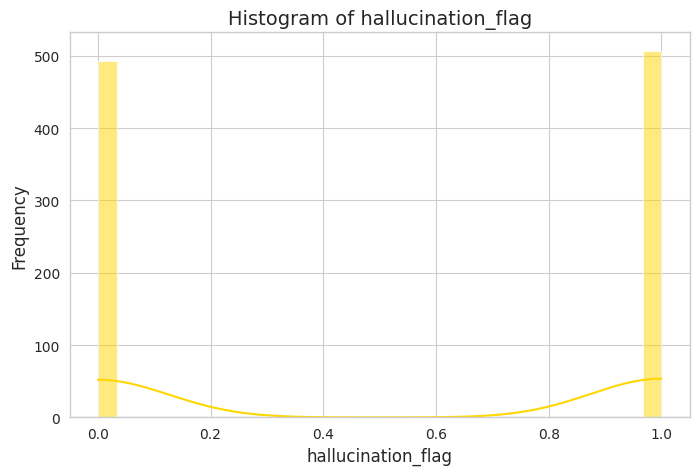

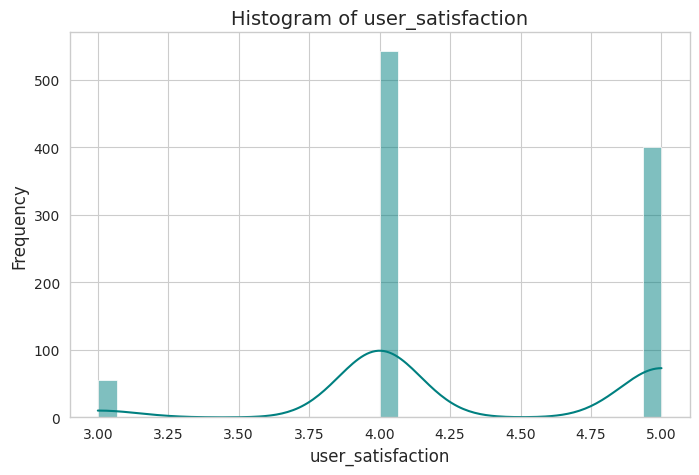

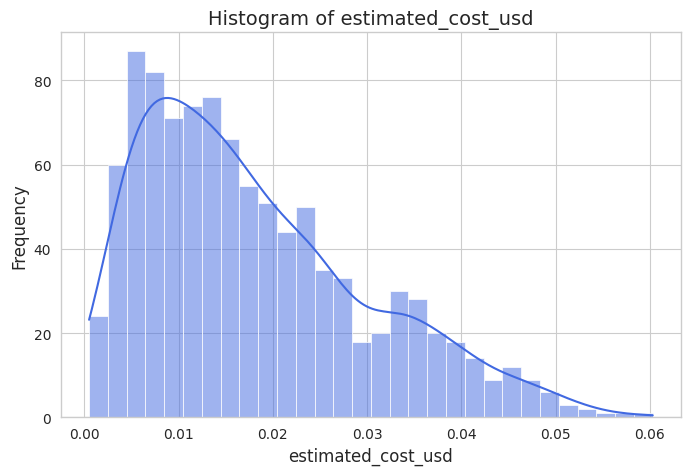

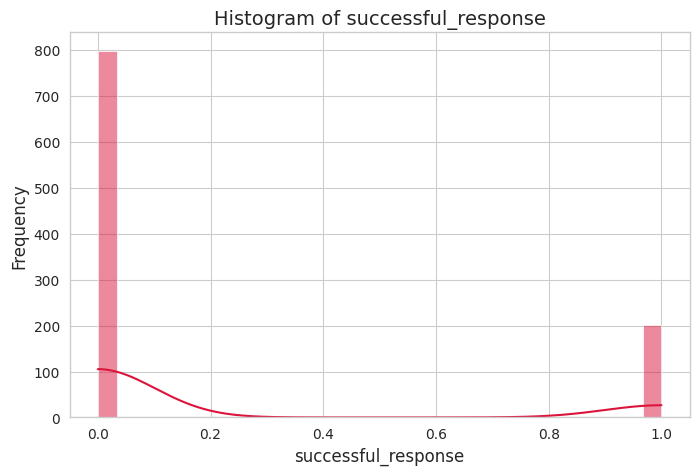

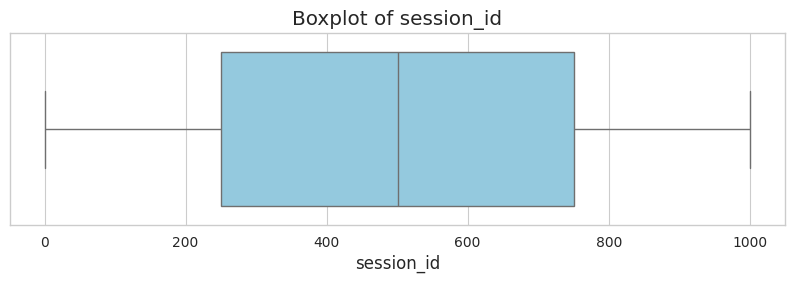

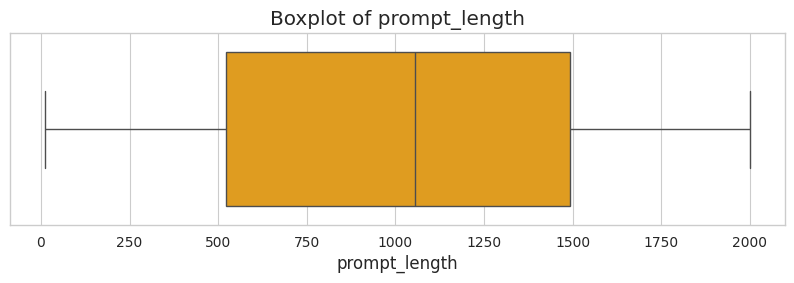

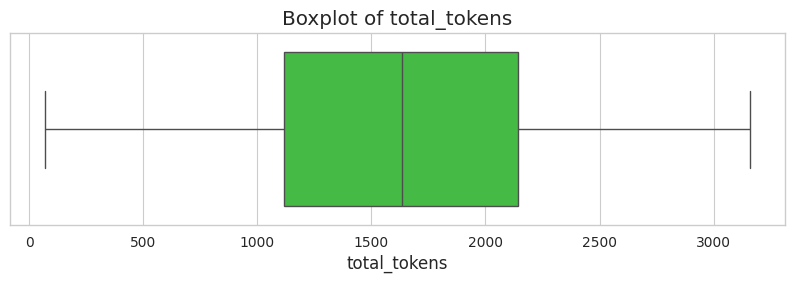

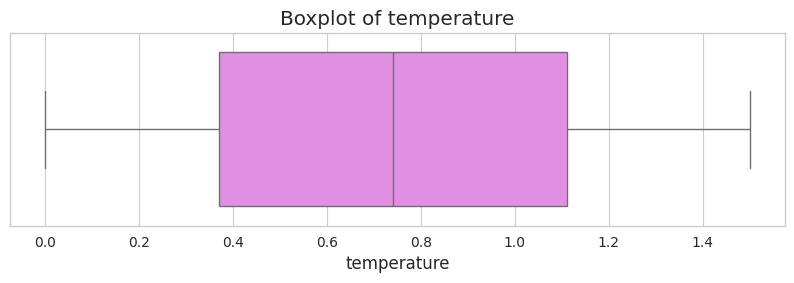

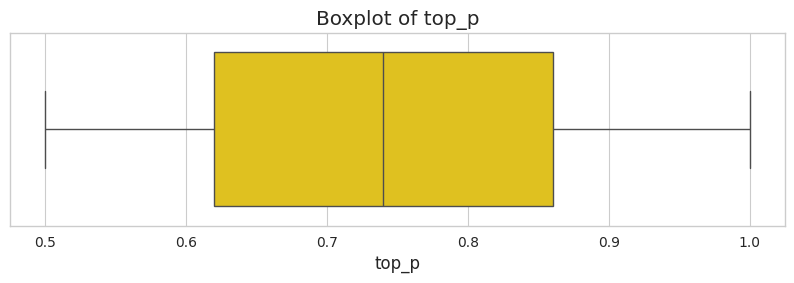

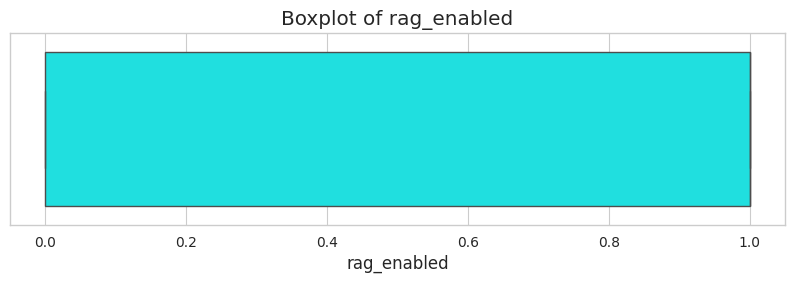

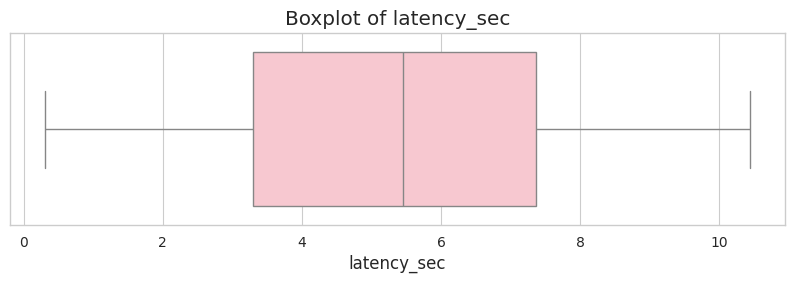

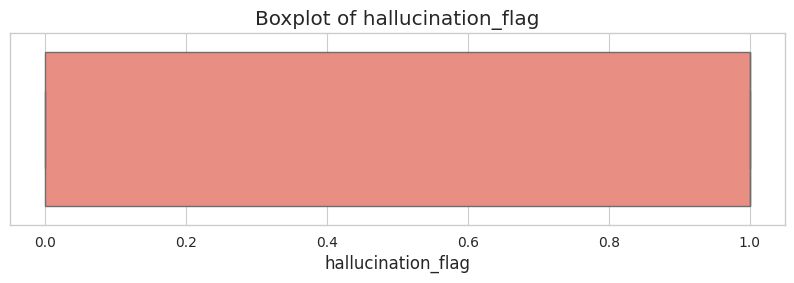

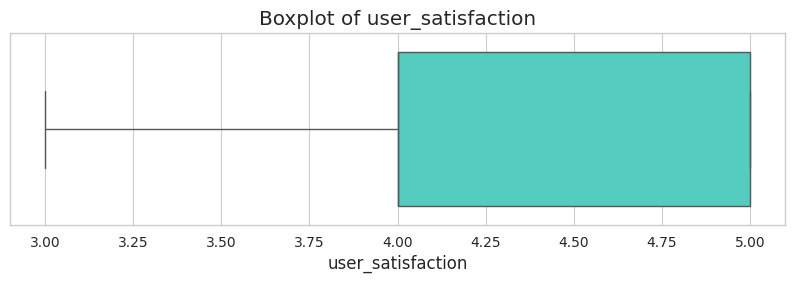

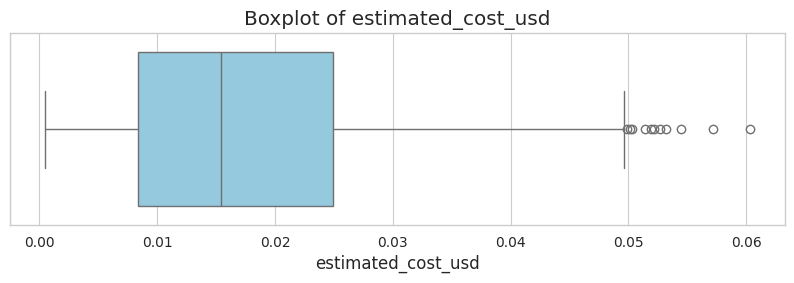

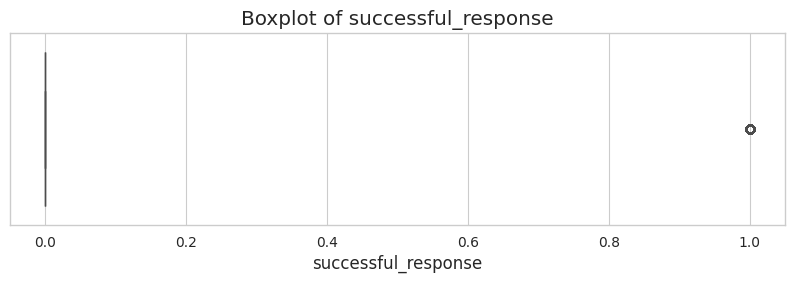

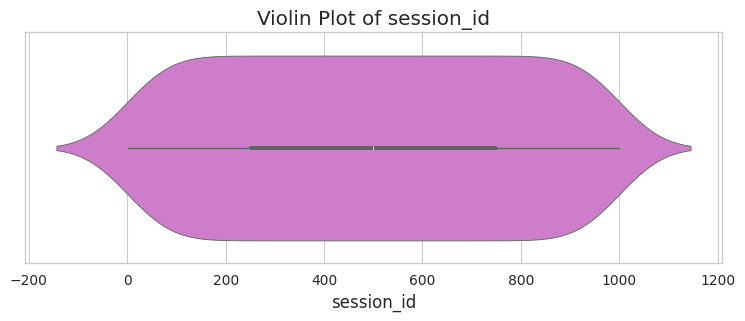

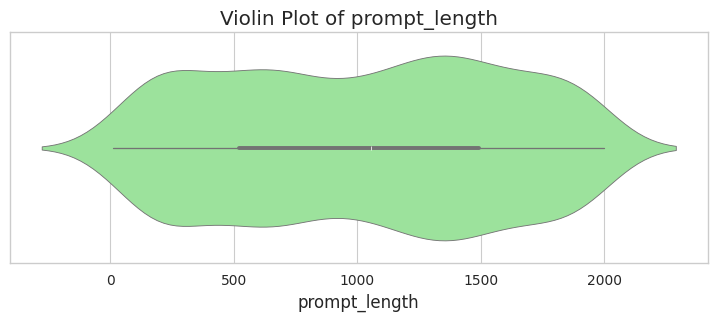

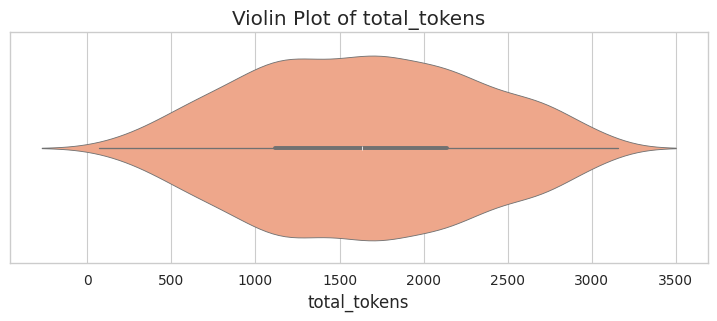

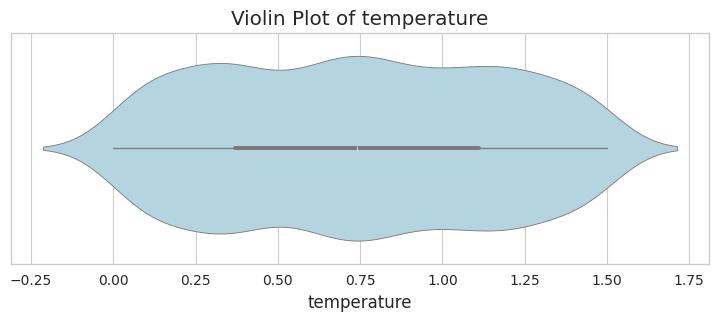

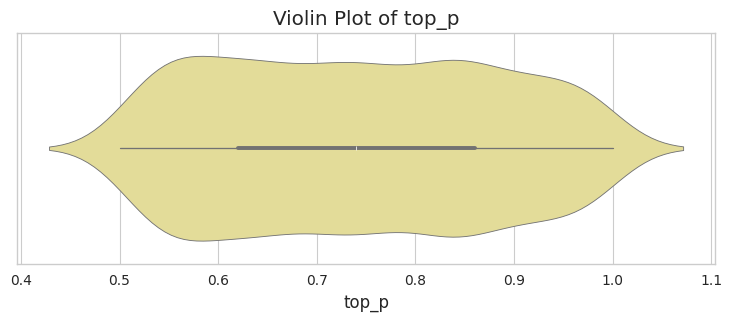

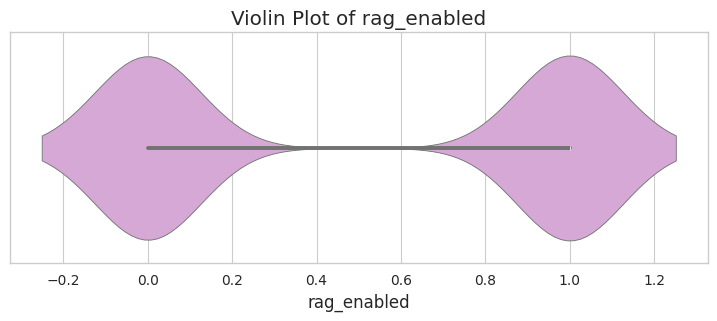

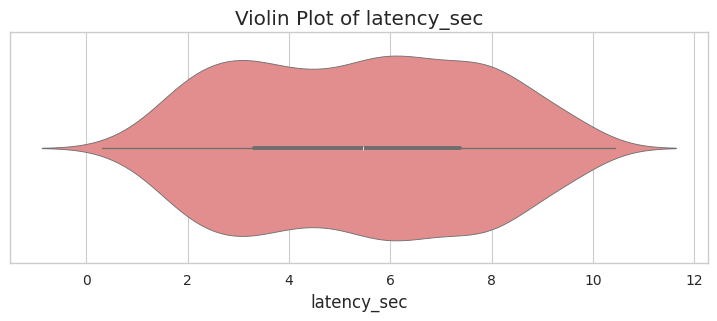

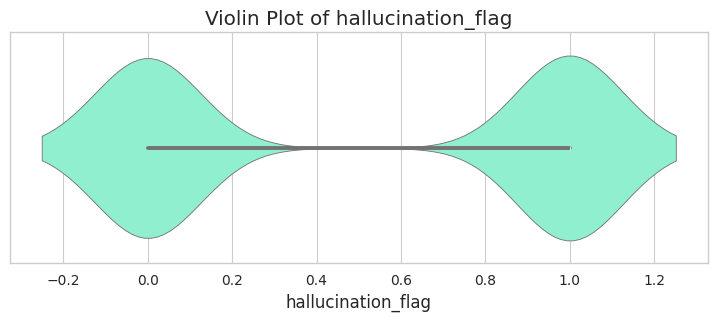

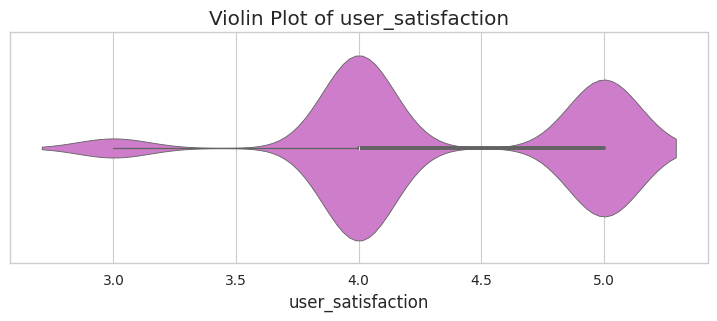

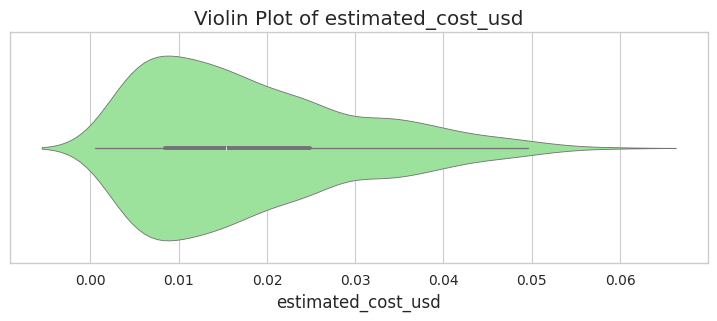

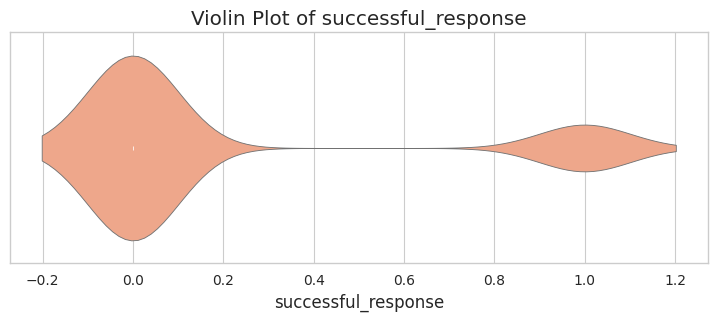

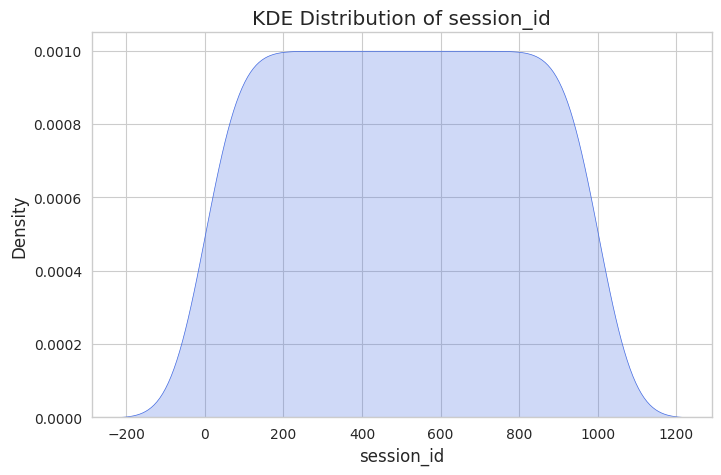

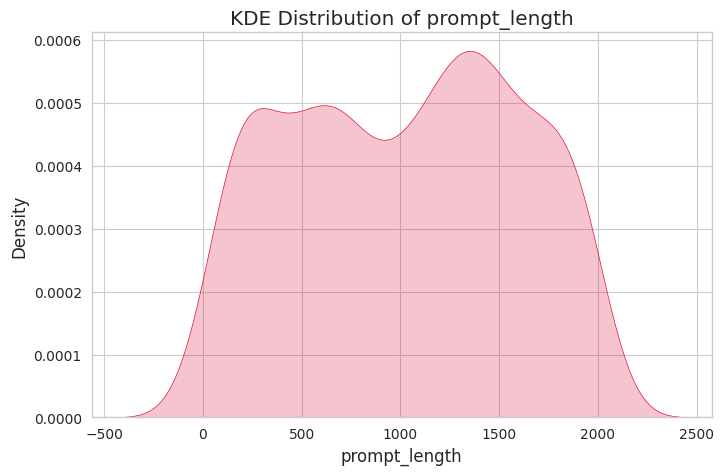

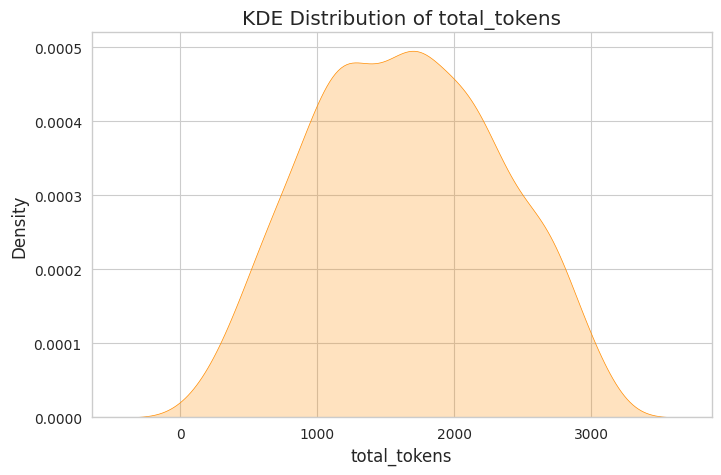

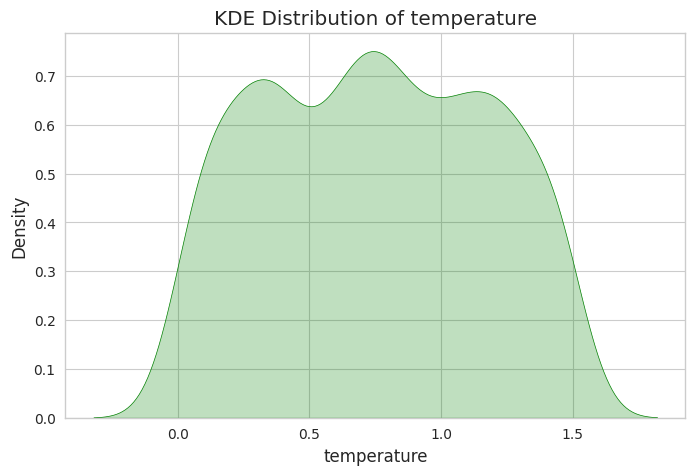

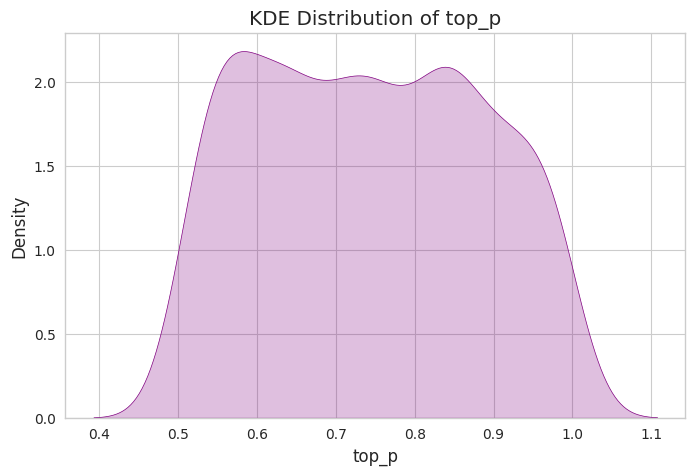

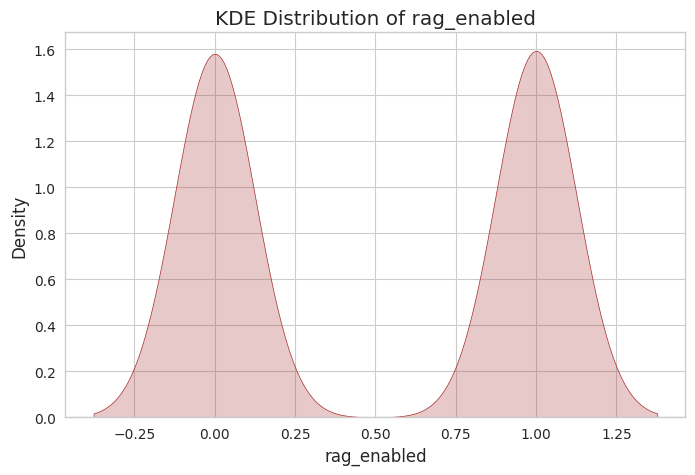

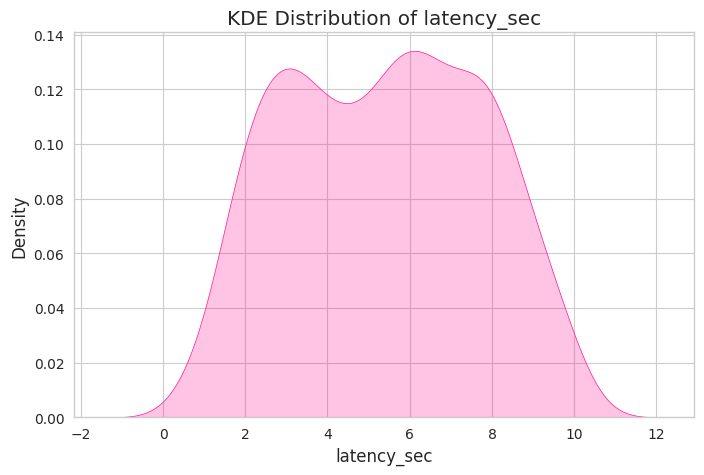

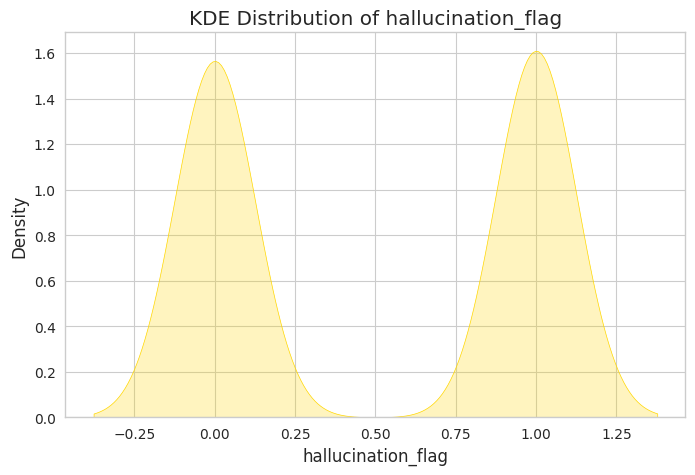

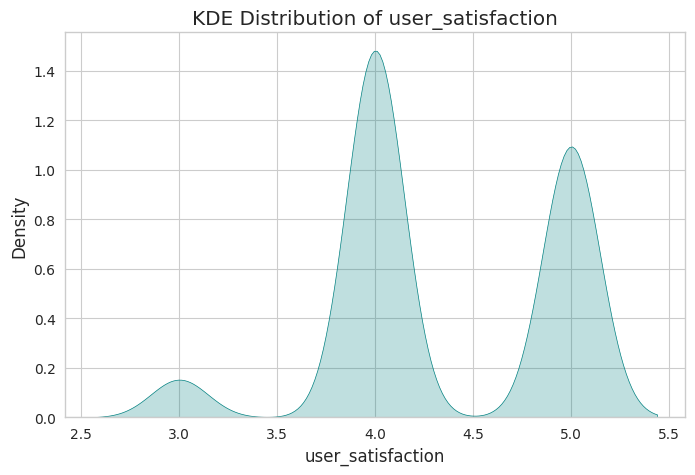

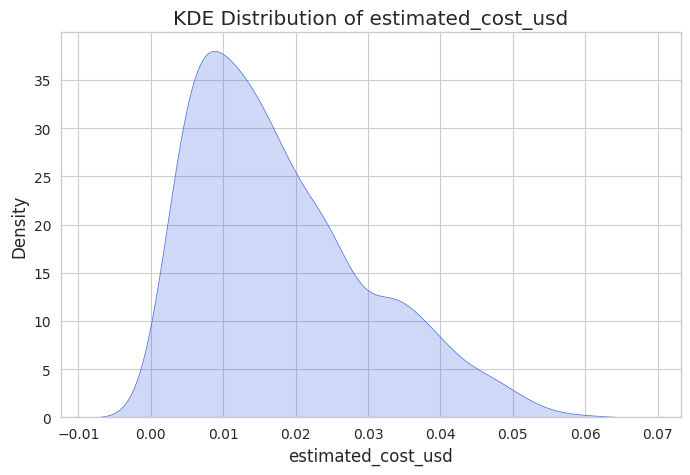

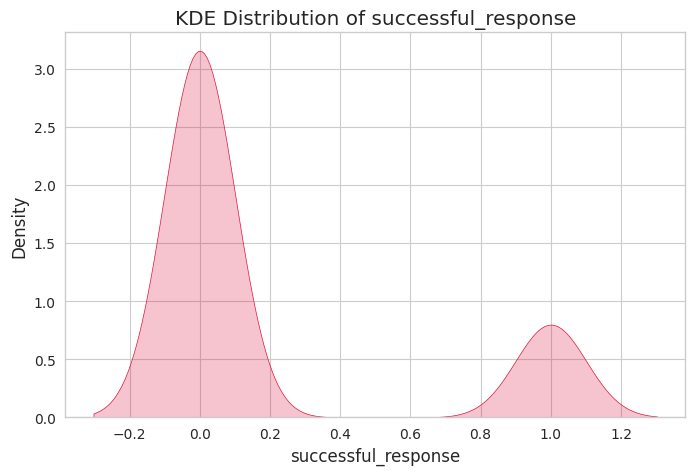



SKEWNESS
session_id             0.000000
prompt_length         -0.048530
total_tokens           0.045632
temperature            0.020613
top_p                  0.074517
rag_enabled           -0.008012
latency_sec            0.010408
hallucination_flag    -0.028045
user_satisfaction     -0.233794
estimated_cost_usd     0.844728
successful_response    1.486693
dtype: float64


KURTOSIS
session_id            -1.200000
prompt_length         -1.209059
total_tokens          -0.772347
temperature           -1.148924
top_p                 -1.180144
rag_enabled           -2.003948
latency_sec           -1.047576
hallucination_flag    -2.003224
user_satisfaction     -0.679510
estimated_cost_usd     0.035010
successful_response    0.210674
dtype: float64


PART 1 COMPLETED SUCCESSFULLY


In [11]:
# =============================================================================
# PART 1 : DATASET OVERVIEW & NUMERICAL VISUALIZATION
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# Plot Style
# =============================================================================

plt.style.use("ggplot")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# =============================================================================
# DATASET OVERVIEW
# =============================================================================

print("="*80)
print("DATASET SHAPE")
print("="*80)

print(df.shape)

print("\n")

print("="*80)
print("FIRST 5 ROWS")
print("="*80)

print(df.head())

print("\n")

print("="*80)
print("LAST 5 ROWS")
print("="*80)

print(df.tail())

print("\n")

print("="*80)
print("DATASET INFO")
print("="*80)

print(df.info())

print("\n")

print("="*80)
print("DATA TYPES")
print("="*80)

print(df.dtypes)

print("\n")

print("="*80)
print("STATISTICAL SUMMARY")
print("="*80)

print(df.describe(include="all"))

# =============================================================================
# MISSING VALUES
# =============================================================================

missing = df.isnull().sum()

print("\n")
print("="*80)
print("MISSING VALUES")
print("="*80)
print(missing)

plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cmap="viridis",
    cbar=True,
    yticklabels=False
)

plt.title("Missing Values Heatmap",fontsize=15)

plt.show()

plt.figure(figsize=(12,6))

colors = ["red" if i>0 else "steelblue" for i in missing]

plt.barh(
    missing.index,
    missing.values,
    color=colors
)

plt.title("Missing Values Count")

plt.xlabel("Count")

plt.show()

# =============================================================================
# DUPLICATE VALUES
# =============================================================================

duplicates = df.duplicated().sum()

print("\n")
print("="*80)
print("DUPLICATE VALUES")
print("="*80)
print("Duplicate Rows :",duplicates)

plt.figure(figsize=(5,5))

plt.pie(
    [duplicates,len(df)-duplicates],
    labels=["Duplicate","Unique"],
    autopct="%1.1f%%",
    colors=["red","green"],
    explode=(0.05,0)
)

plt.title("Duplicate Records")

plt.show()

# =============================================================================
# COLUMN TYPES
# =============================================================================

numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(include="object").columns

print("\n")

print("="*80)
print("NUMERICAL COLUMNS")
print("="*80)

print(list(numerical_columns))

print("\n")

print("="*80)
print("CATEGORICAL COLUMNS")
print("="*80)

print(list(categorical_columns))

# =============================================================================
# HISTOGRAMS
# =============================================================================

hist_colors = [
    "royalblue",
    "crimson",
    "darkorange",
    "green",
    "purple",
    "brown",
    "deeppink",
    "gold",
    "teal"
]

for i,col in enumerate(numerical_columns):

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color=hist_colors[i%len(hist_colors)]
    )

    plt.title(f"Histogram of {col}",fontsize=14)

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.grid(True)

    plt.show()

# =============================================================================
# BOXPLOTS
# =============================================================================

box_colors = [
    "skyblue",
    "orange",
    "limegreen",
    "violet",
    "gold",
    "cyan",
    "pink",
    "salmon",
    "turquoise"
]

for i,col in enumerate(numerical_columns):

    plt.figure(figsize=(10,2.5))

    sns.boxplot(
        x=df[col],
        color=box_colors[i%len(box_colors)]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

# =============================================================================
# VIOLIN PLOTS
# =============================================================================

violin_colors = [
    "orchid",
    "lightgreen",
    "lightsalmon",
    "lightblue",
    "khaki",
    "plum",
    "lightcoral",
    "aquamarine"
]

for i,col in enumerate(numerical_columns):

    plt.figure(figsize=(9,3))

    sns.violinplot(
        x=df[col],
        color=violin_colors[i%len(violin_colors)]
    )

    plt.title(f"Violin Plot of {col}")

    plt.show()

# =============================================================================
# DISTRIBUTION + KDE
# =============================================================================

for i,col in enumerate(numerical_columns):

    plt.figure(figsize=(8,5))

    sns.kdeplot(
        df[col],
        fill=True,
        color=hist_colors[i%len(hist_colors)]
    )

    plt.title(f"KDE Distribution of {col}")

    plt.show()

# =============================================================================
# SKEWNESS
# =============================================================================

print("\n")
print("="*80)
print("SKEWNESS")
print("="*80)

print(df[numerical_columns].skew())

# =============================================================================
# KURTOSIS
# =============================================================================

print("\n")
print("="*80)
print("KURTOSIS")
print("="*80)

print(df[numerical_columns].kurt())

print("\n")
print("="*80)
print("PART 1 COMPLETED SUCCESSFULLY")
print("="*80)

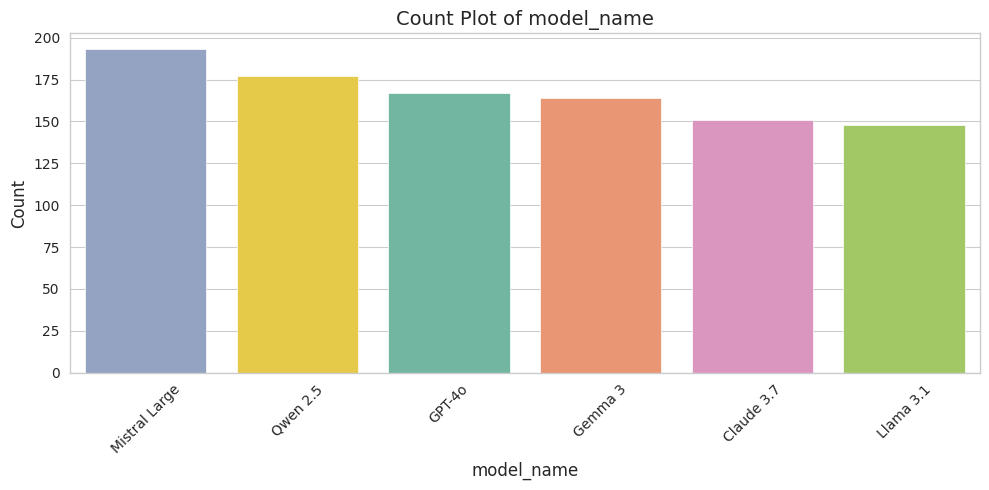

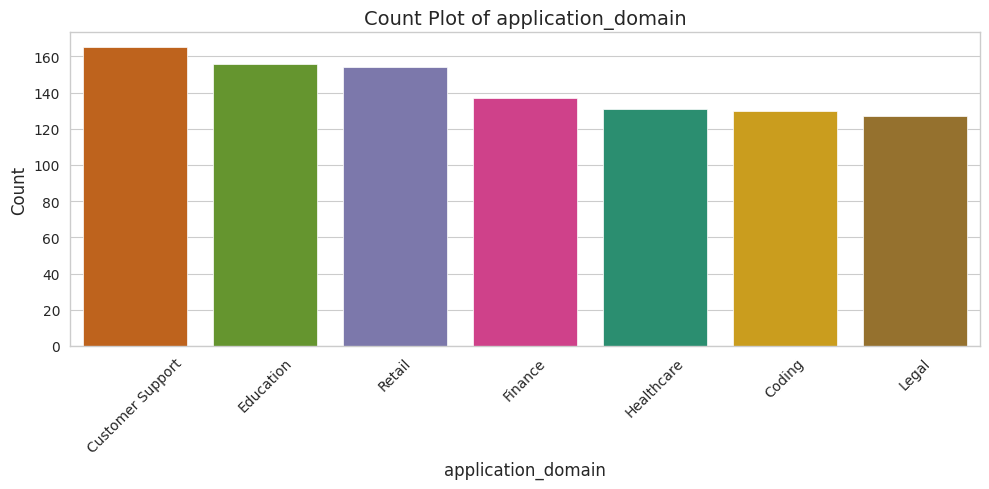

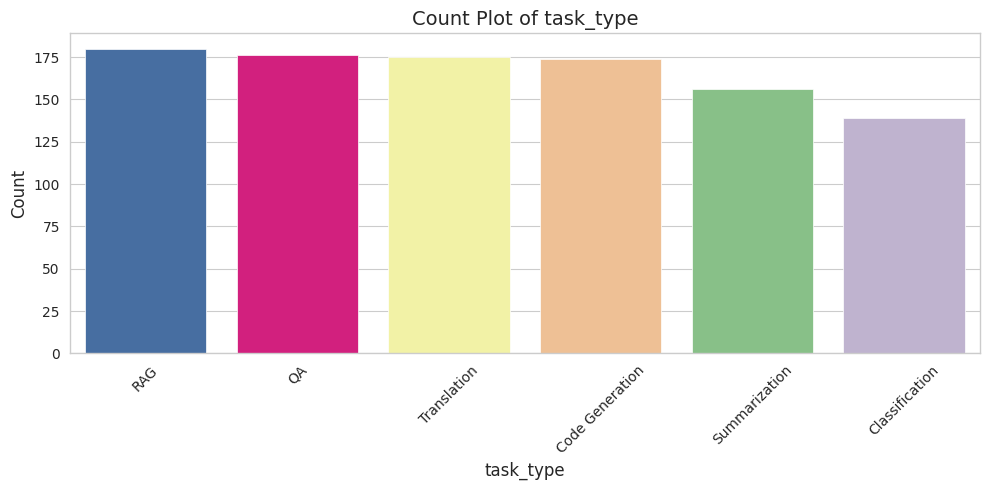

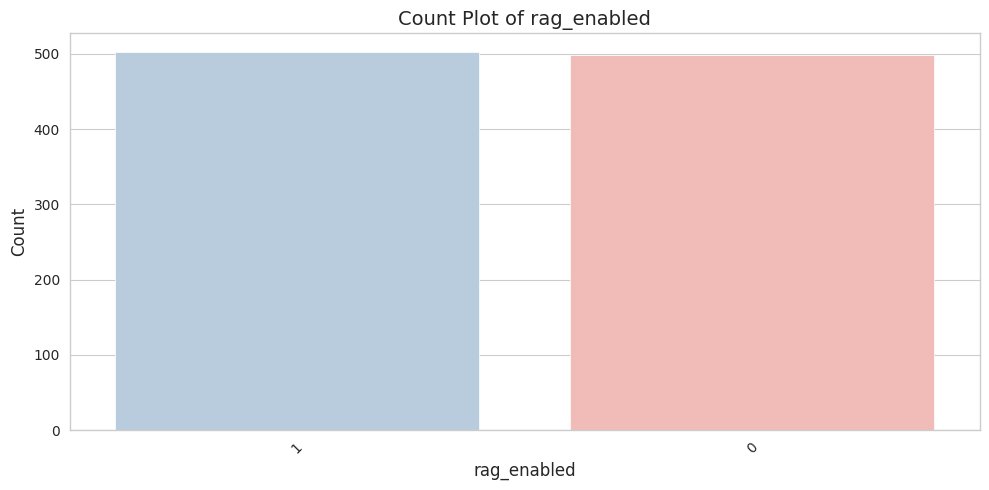

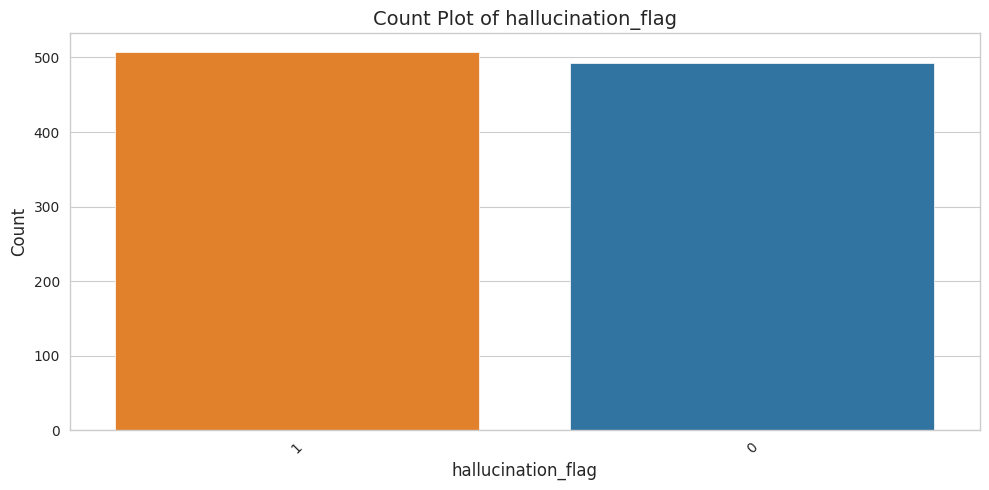

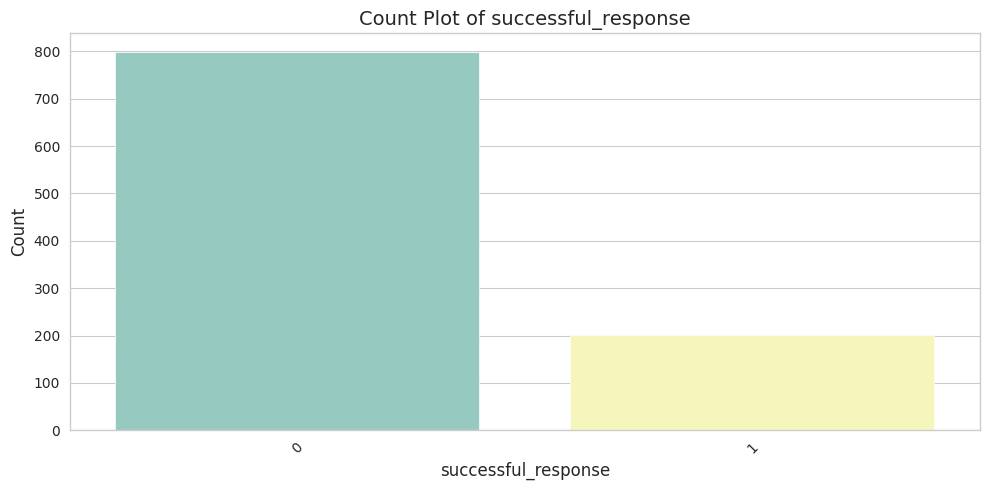

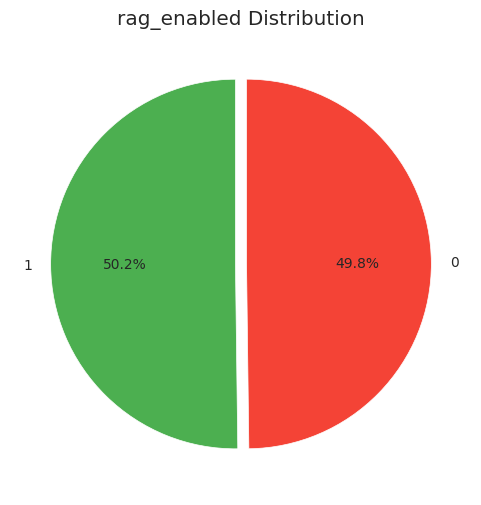

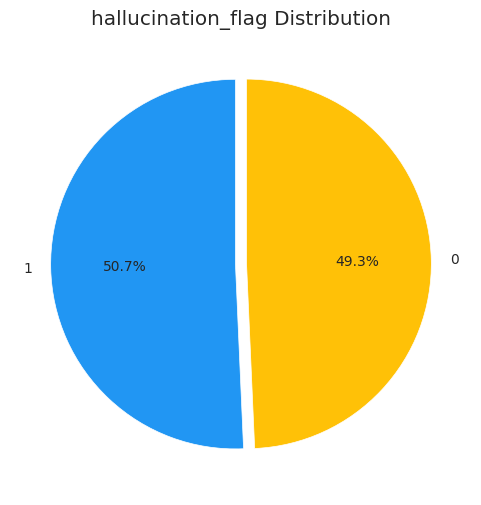

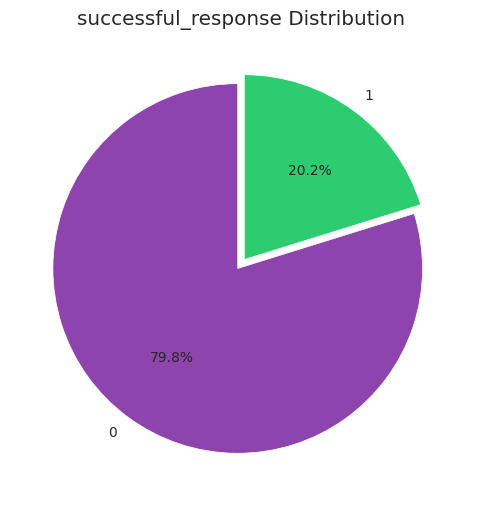

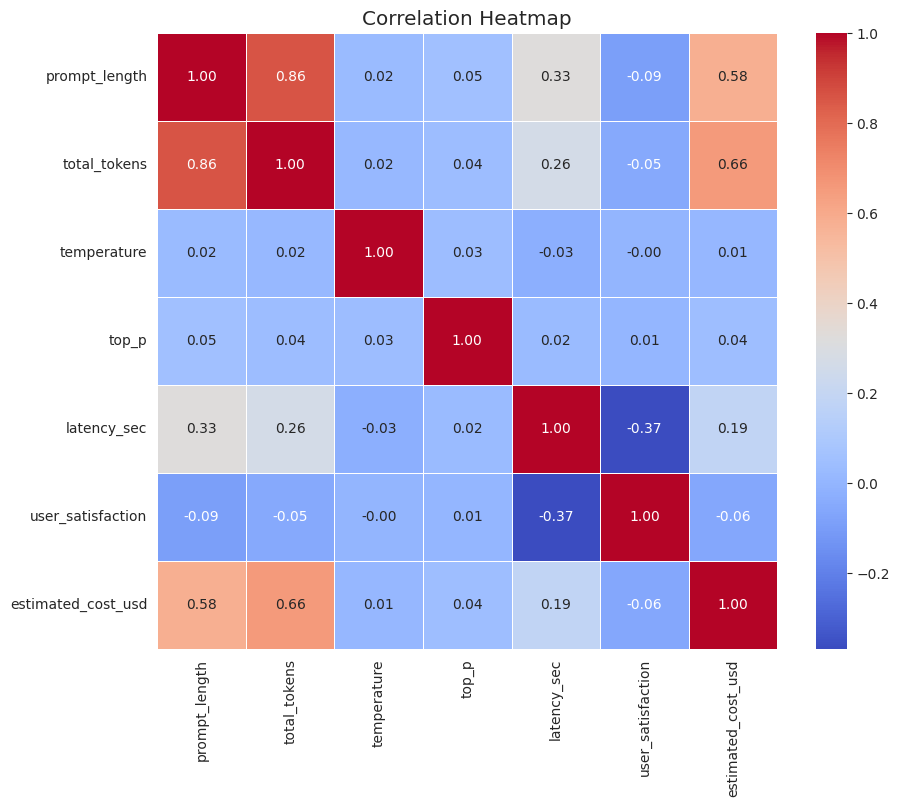

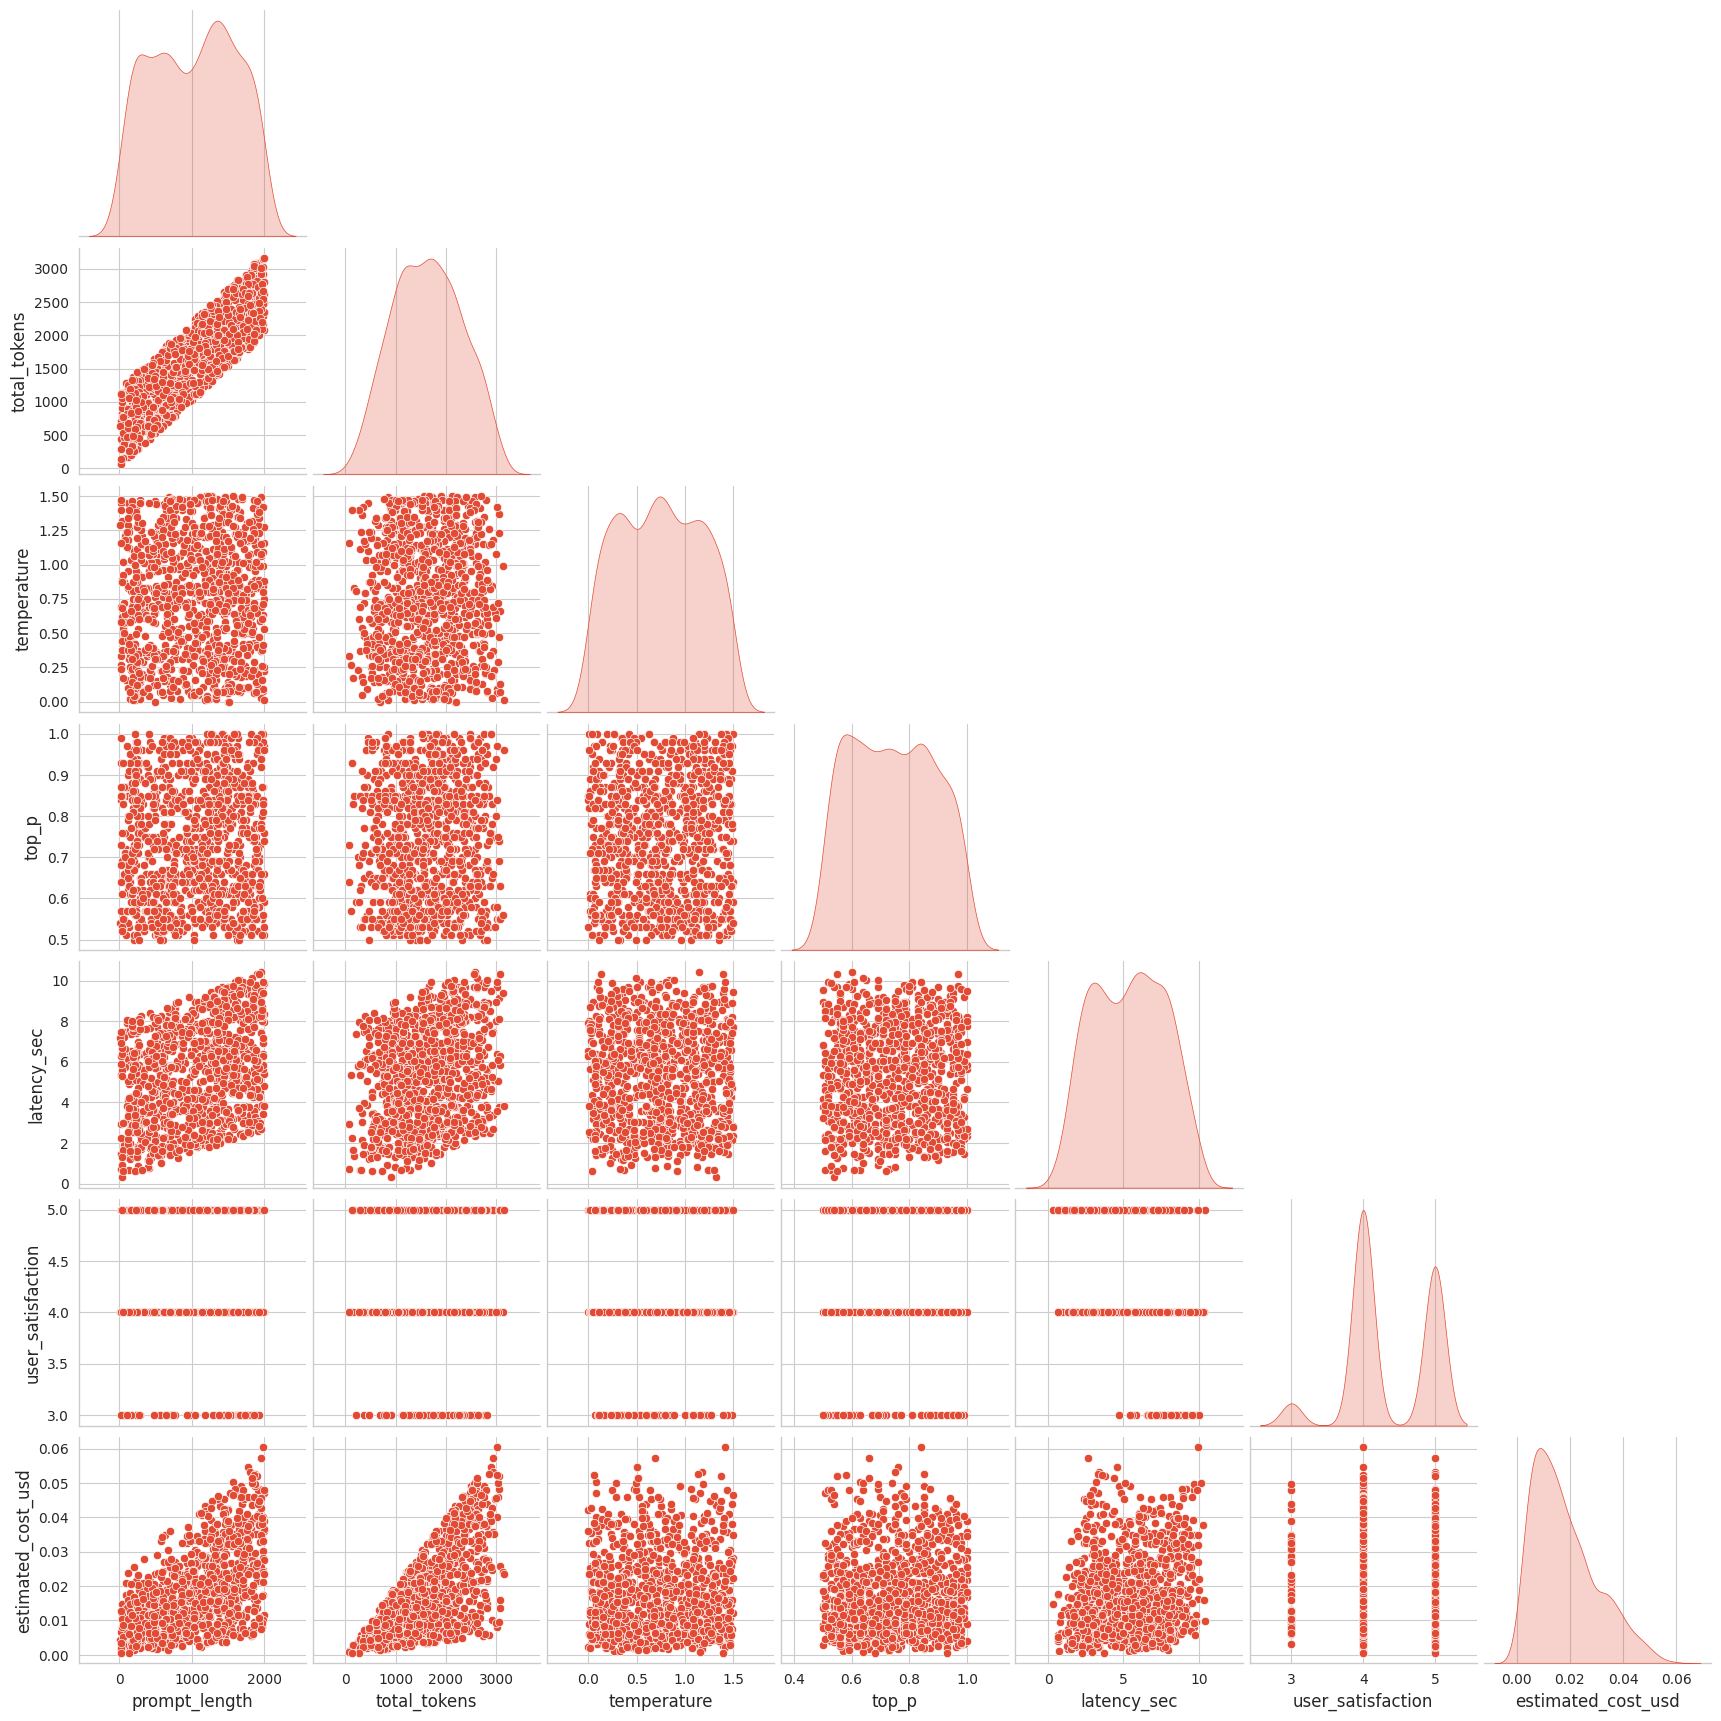

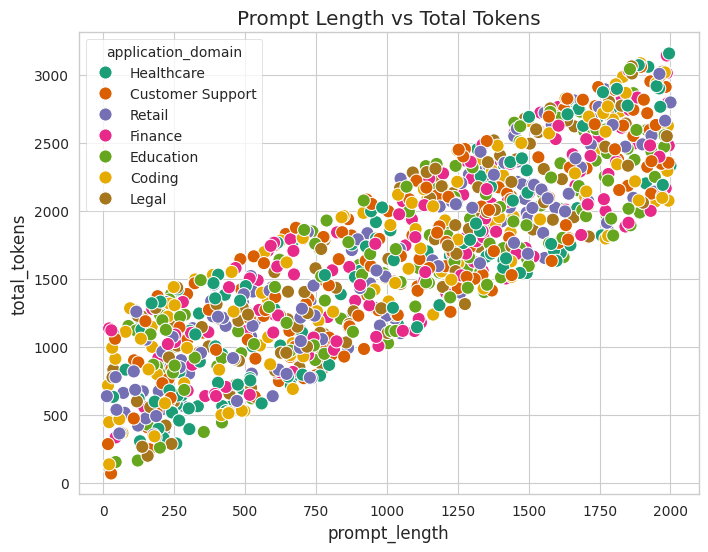

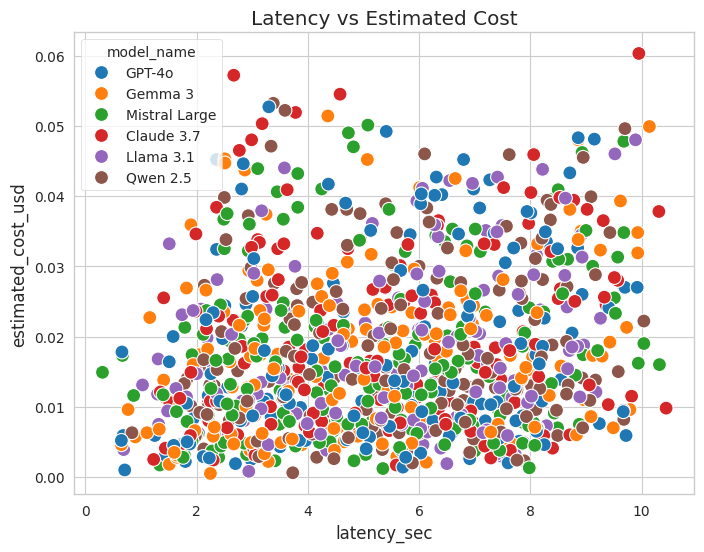

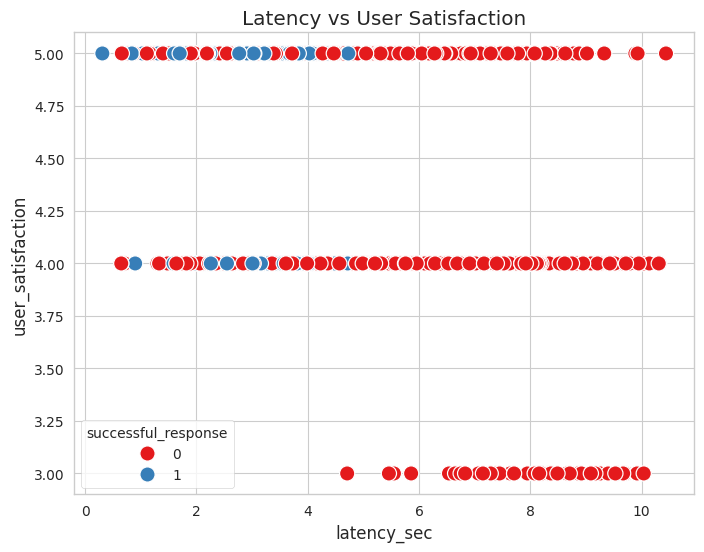

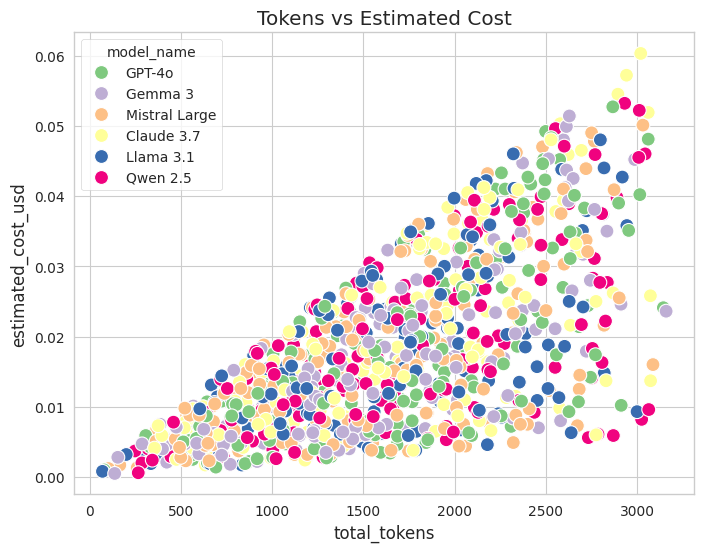

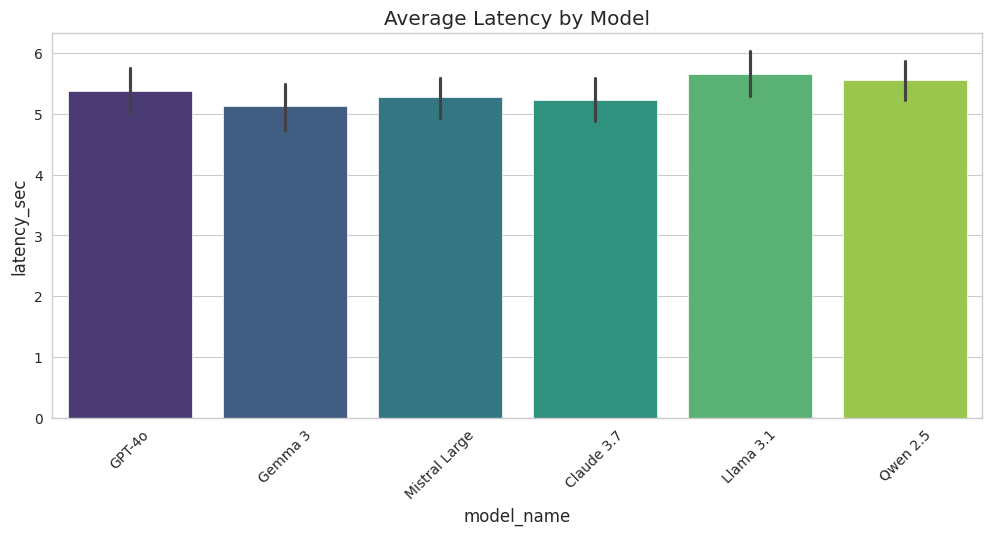

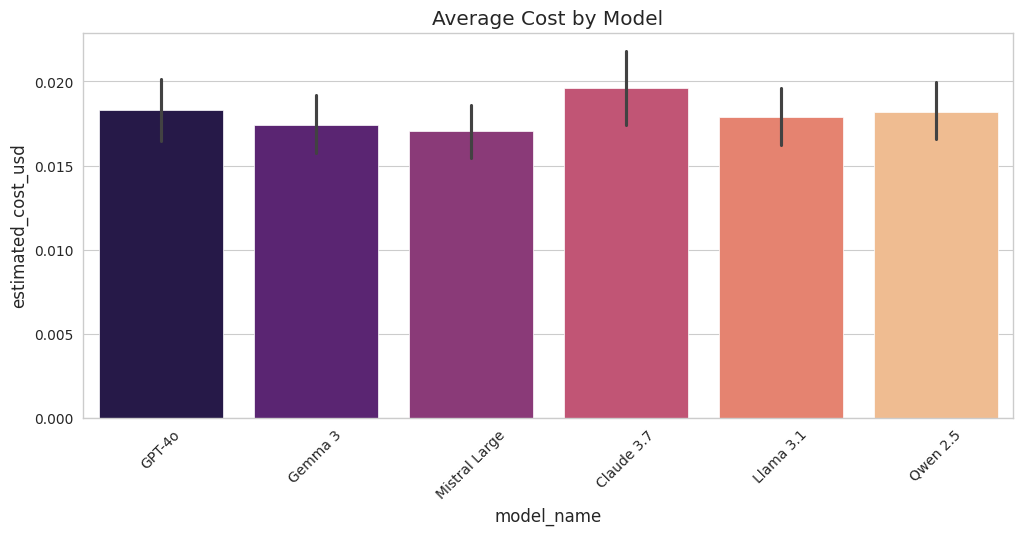

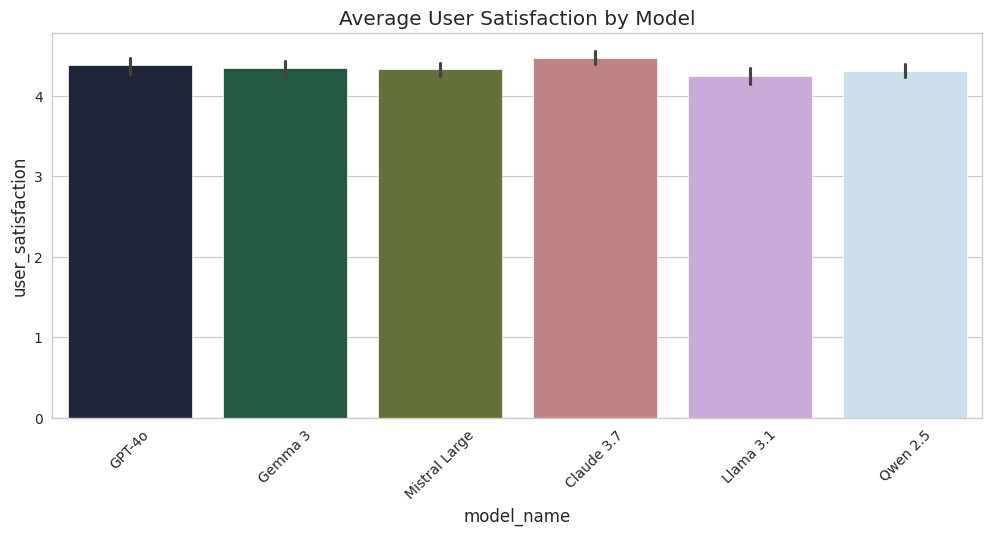

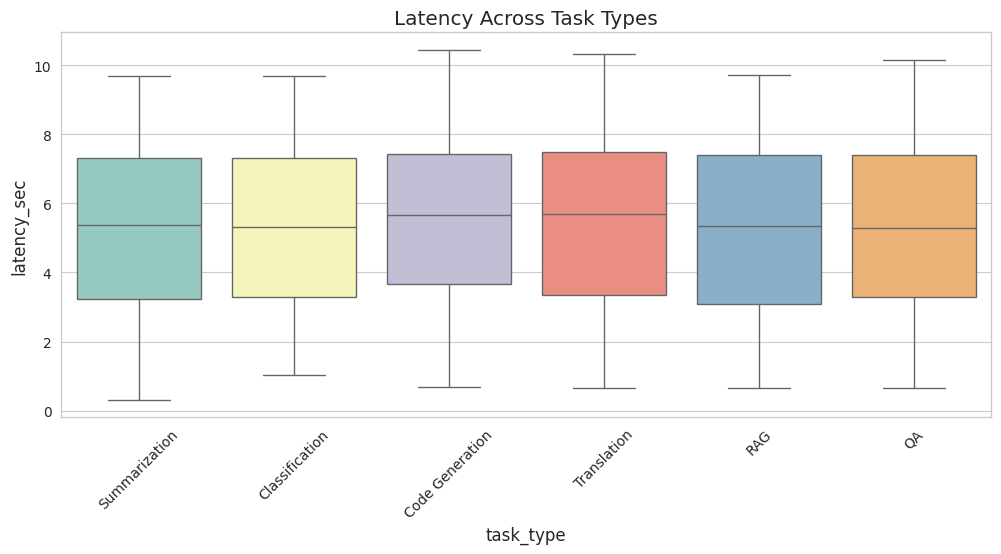

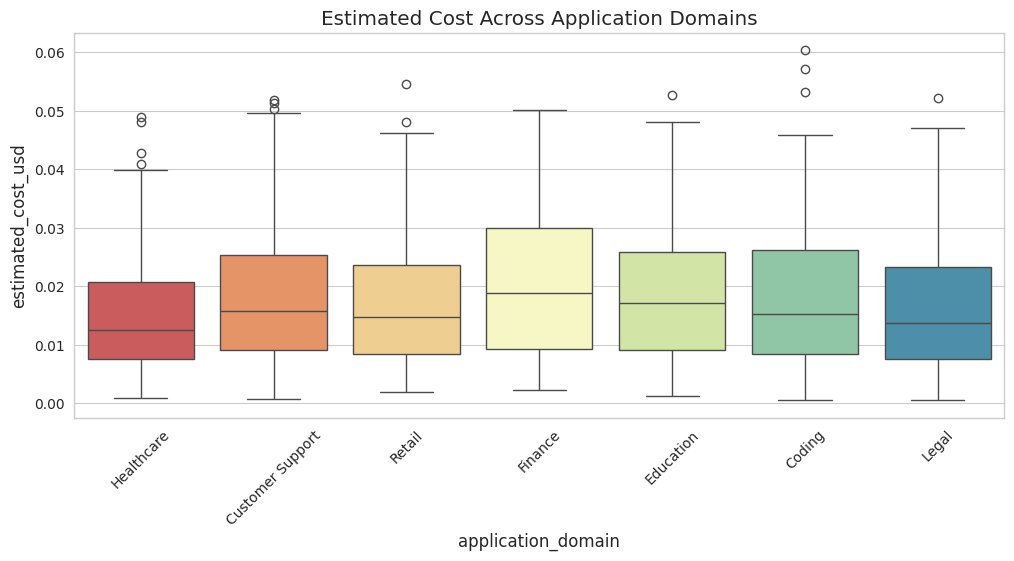

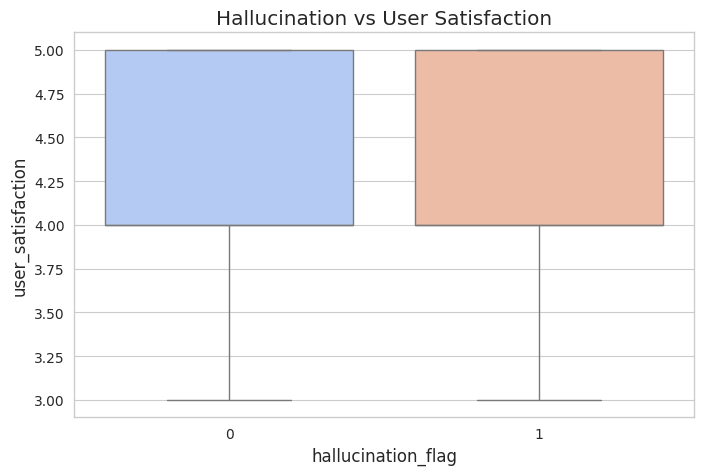

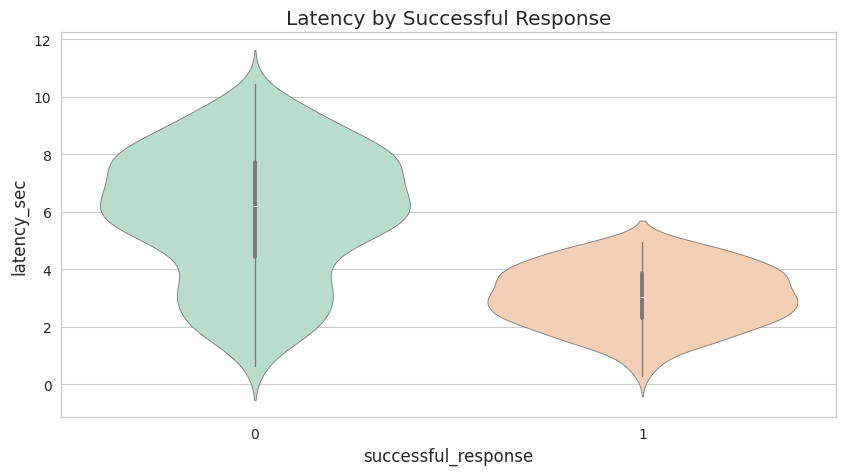

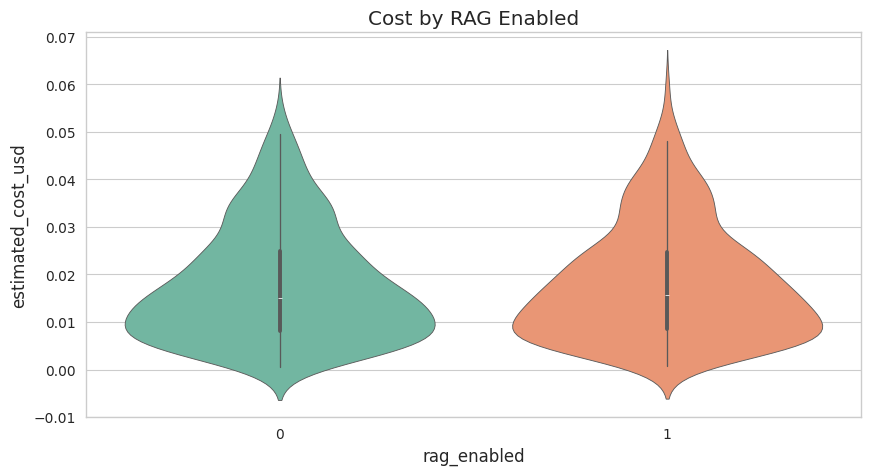

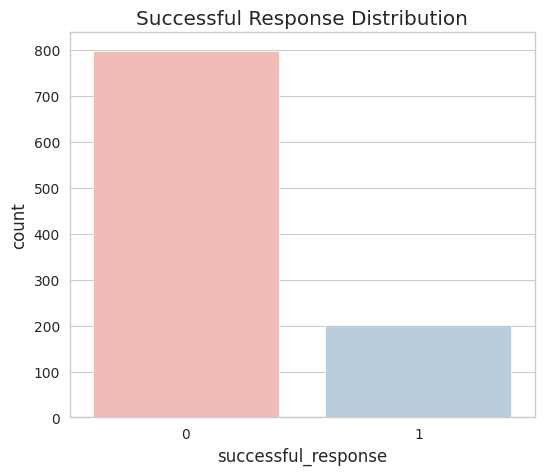

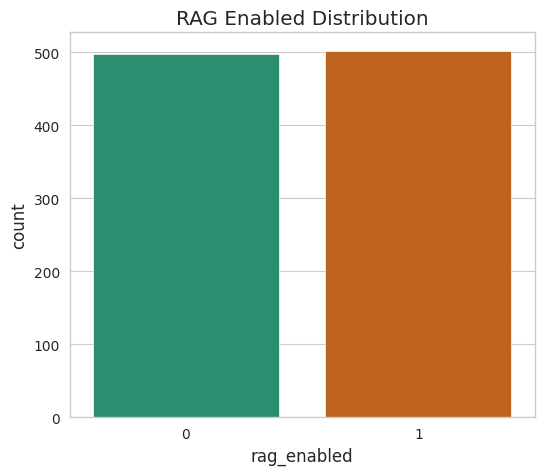

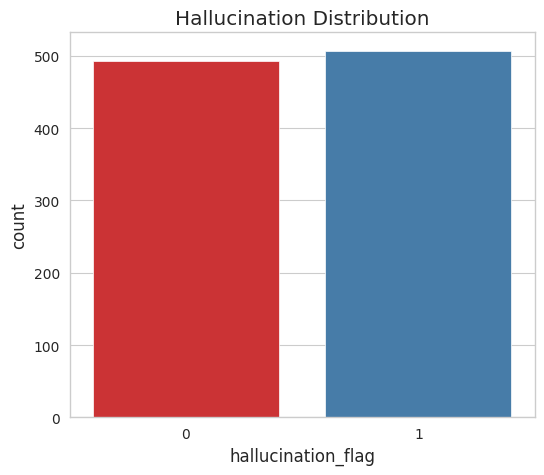

PART 2 COMPLETED SUCCESSFULLY


In [12]:
# =============================================================================
# PART 2 : CATEGORICAL & RELATIONSHIP VISUALIZATIONS
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use("ggplot")
sns.set_style("whitegrid")

# =============================================================================
# CATEGORICAL COLUMNS
# =============================================================================

categorical_columns = [
    "model_name",
    "application_domain",
    "task_type",
    "rag_enabled",
    "hallucination_flag",
    "successful_response"
]

# =============================================================================
# COUNT PLOTS
# =============================================================================

palettes = [
    "Set2",
    "Dark2",
    "Accent",
    "Pastel1",
    "tab10",
    "Set3"
]

for i, col in enumerate(categorical_columns):

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=df,
        x=col,
        hue=col,
        palette=palettes[i % len(palettes)],
        legend=False,
        order=df[col].value_counts().index
    )

    plt.title(f"Count Plot of {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# =============================================================================
# PIE CHARTS
# =============================================================================

pie_columns = [
    "rag_enabled",
    "hallucination_flag",
    "successful_response"
]

pie_colors = [
    ["#4CAF50","#F44336"],
    ["#2196F3","#FFC107"],
    ["#8E44AD","#2ECC71"]
]

for col, clr in zip(pie_columns, pie_colors):

    plt.figure(figsize=(6,6))

    df[col].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%",
        startangle=90,
        colors=clr,
        explode=[0.03]*len(df[col].value_counts())
    )

    plt.ylabel("")
    plt.title(f"{col} Distribution")

    plt.show()

# =============================================================================
# NUMERICAL COLUMNS
# =============================================================================

numerical_columns = [
    "prompt_length",
    "total_tokens",
    "temperature",
    "top_p",
    "latency_sec",
    "user_satisfaction",
    "estimated_cost_usd"
]

# =============================================================================
# CORRELATION HEATMAP
# =============================================================================

plt.figure(figsize=(10,8))

corr = df[numerical_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# =============================================================================
# PAIR PLOT
# =============================================================================

sns.pairplot(
    df[numerical_columns],
    diag_kind="kde",
    corner=True
)

plt.show()

# =============================================================================
# SCATTER PLOTS
# =============================================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="prompt_length",
    y="total_tokens",
    hue="application_domain",
    palette="Dark2",
    s=90
)

plt.title("Prompt Length vs Total Tokens")

plt.show()


plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="latency_sec",
    y="estimated_cost_usd",
    hue="model_name",
    palette="tab10",
    s=100
)

plt.title("Latency vs Estimated Cost")

plt.show()


plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="latency_sec",
    y="user_satisfaction",
    hue="successful_response",
    palette="Set1",
    s=120
)

plt.title("Latency vs User Satisfaction")

plt.show()


plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="total_tokens",
    y="estimated_cost_usd",
    hue="model_name",
    palette="Accent",
    s=100
)

plt.title("Tokens vs Estimated Cost")

plt.show()

# =============================================================================
# BAR PLOTS
# =============================================================================

plt.figure(figsize=(12,5))

sns.barplot(
    data=df,
    x="model_name",
    y="latency_sec",
    estimator=np.mean,
    palette="viridis"
)

plt.xticks(rotation=45)

plt.title("Average Latency by Model")

plt.show()


plt.figure(figsize=(12,5))

sns.barplot(
    data=df,
    x="model_name",
    y="estimated_cost_usd",
    estimator=np.mean,
    palette="magma"
)

plt.xticks(rotation=45)

plt.title("Average Cost by Model")

plt.show()


plt.figure(figsize=(12,5))

sns.barplot(
    data=df,
    x="model_name",
    y="user_satisfaction",
    estimator=np.mean,
    palette="cubehelix"
)

plt.xticks(rotation=45)

plt.title("Average User Satisfaction by Model")

plt.show()

# =============================================================================
# BOXPLOTS
# =============================================================================

plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="task_type",
    y="latency_sec",
    palette="Set3"
)

plt.xticks(rotation=45)

plt.title("Latency Across Task Types")

plt.show()


plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="application_domain",
    y="estimated_cost_usd",
    palette="Spectral"
)

plt.xticks(rotation=45)

plt.title("Estimated Cost Across Application Domains")

plt.show()


plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="hallucination_flag",
    y="user_satisfaction",
    palette="coolwarm"
)

plt.title("Hallucination vs User Satisfaction")

plt.show()

# =============================================================================
# VIOLIN PLOTS
# =============================================================================

plt.figure(figsize=(10,5))

sns.violinplot(
    data=df,
    x="successful_response",
    y="latency_sec",
    palette="Pastel2"
)

plt.title("Latency by Successful Response")

plt.show()


plt.figure(figsize=(10,5))

sns.violinplot(
    data=df,
    x="rag_enabled",
    y="estimated_cost_usd",
    palette="Set2"
)

plt.title("Cost by RAG Enabled")

plt.show()

# =============================================================================
# SUCCESSFUL RESPONSE COUNT
# =============================================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="successful_response",
    hue="successful_response",
    palette="Pastel1",
    legend=False
)

plt.title("Successful Response Distribution")

plt.show()

# =============================================================================
# RAG ENABLED COUNT
# =============================================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="rag_enabled",
    hue="rag_enabled",
    palette="Dark2",
    legend=False
)

plt.title("RAG Enabled Distribution")

plt.show()

# =============================================================================
# HALLUCINATION COUNT
# =============================================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="hallucination_flag",
    hue="hallucination_flag",
    palette="Set1",
    legend=False
)

plt.title("Hallucination Distribution")

plt.show()

# =============================================================================
# COMPLETED
# =============================================================================

print("="*80)
print("PART 2 COMPLETED SUCCESSFULLY")
print("="*80)

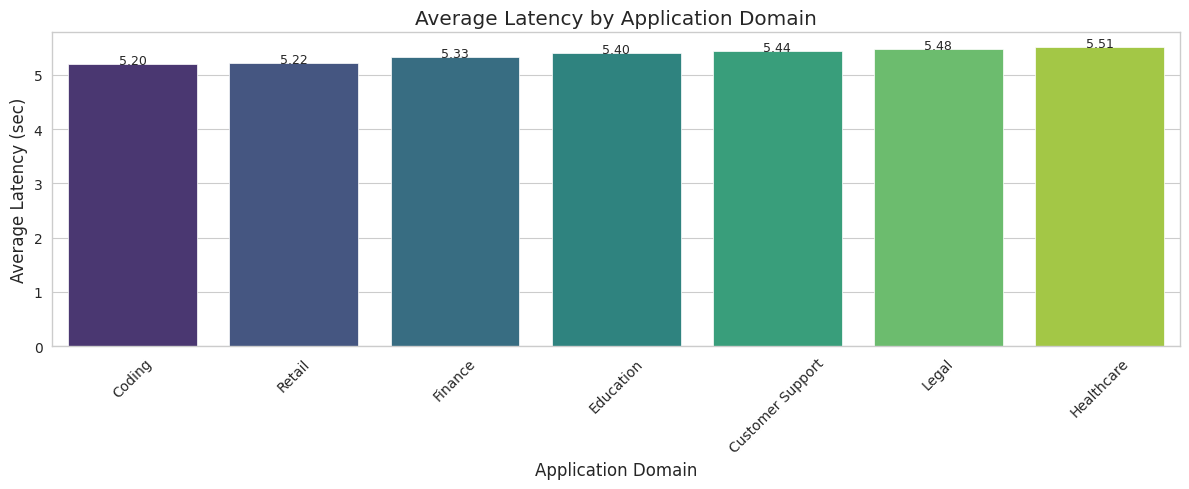

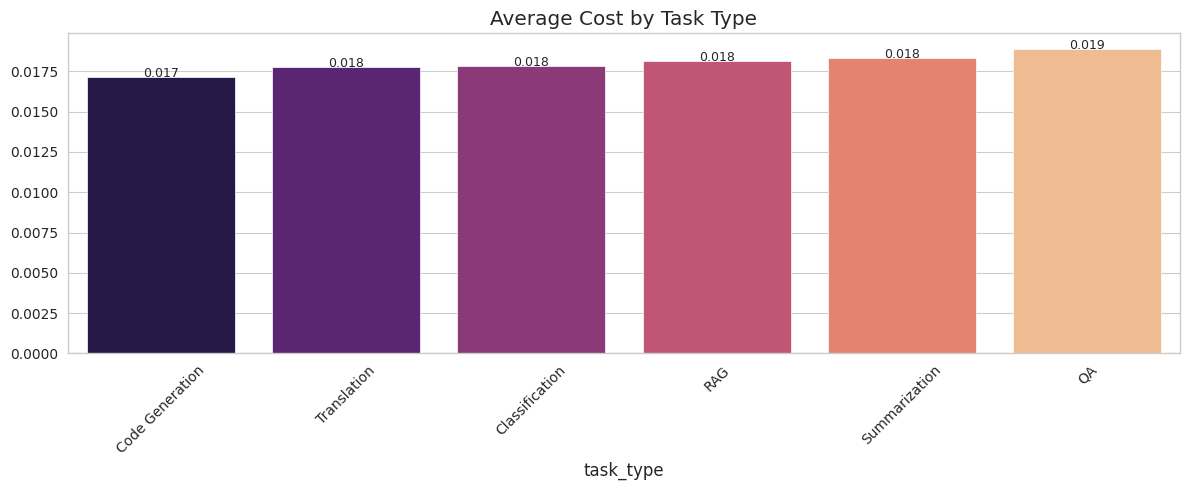

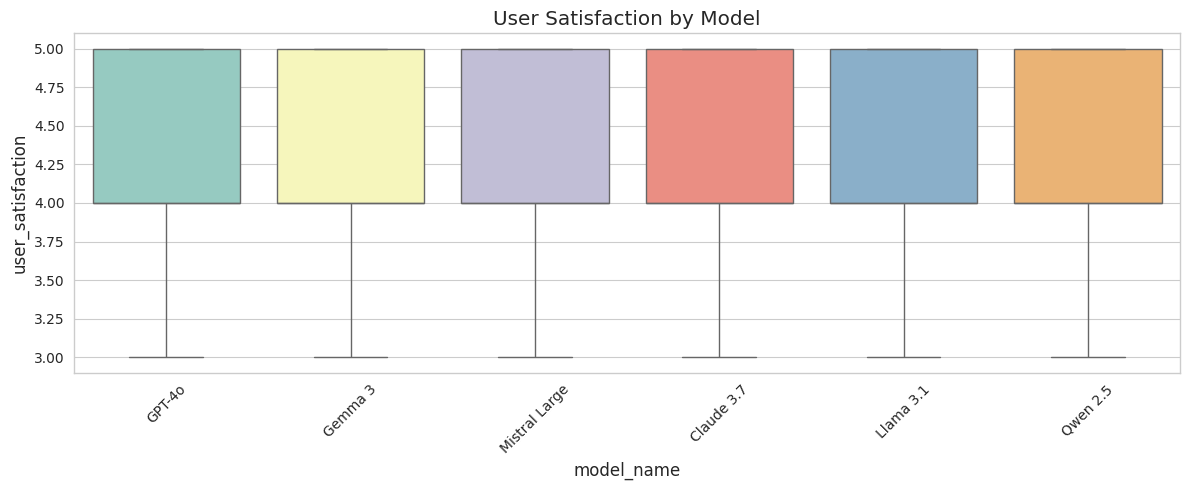

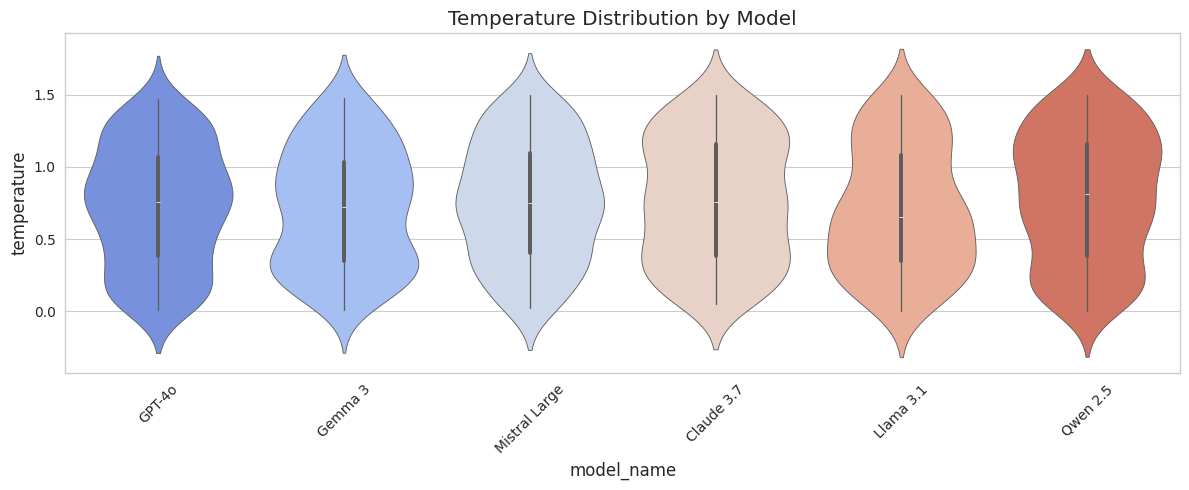

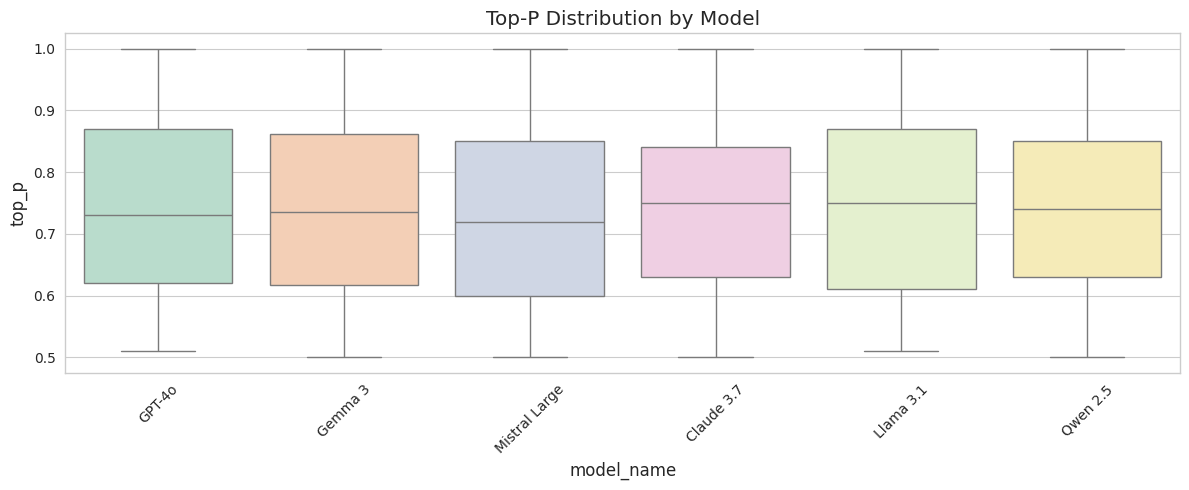

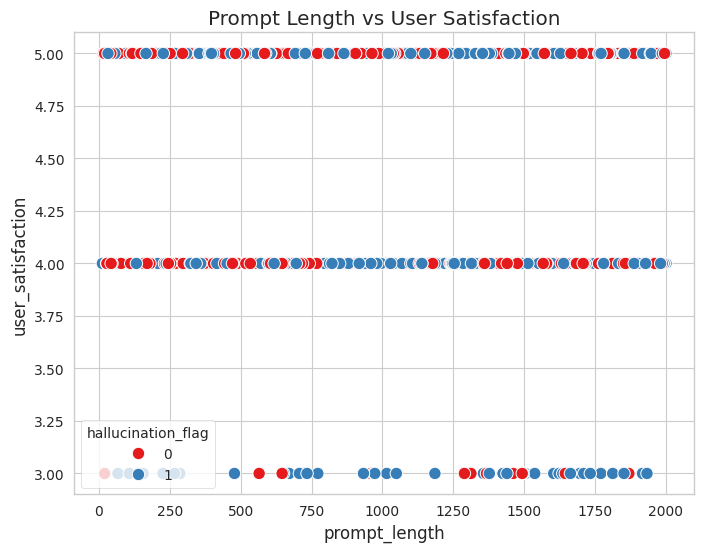

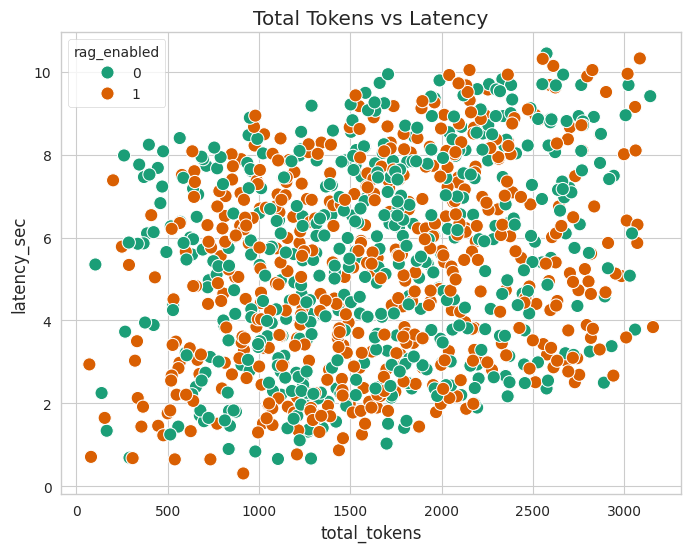

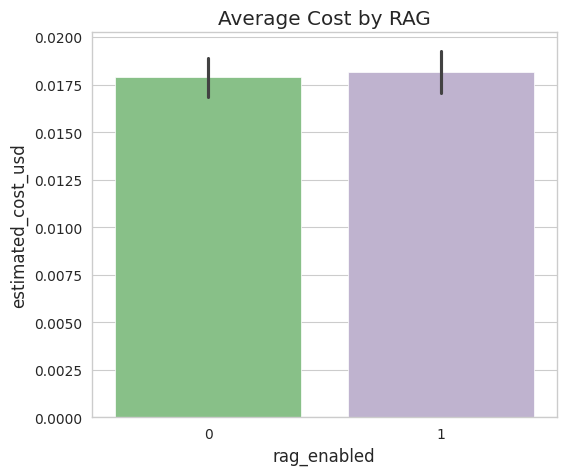

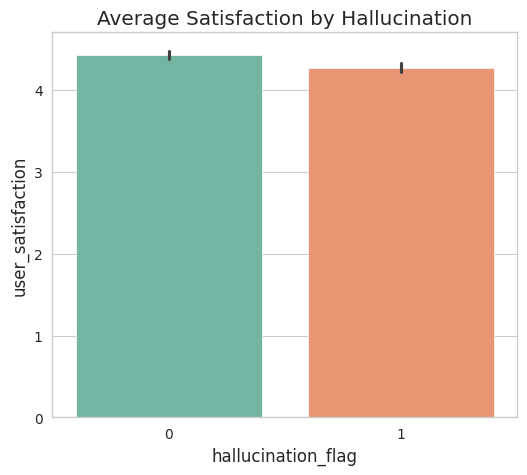

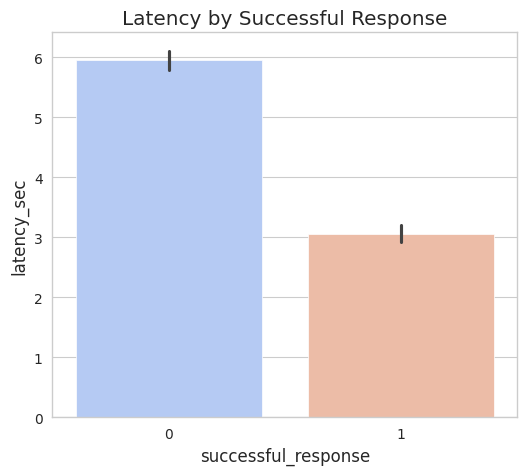

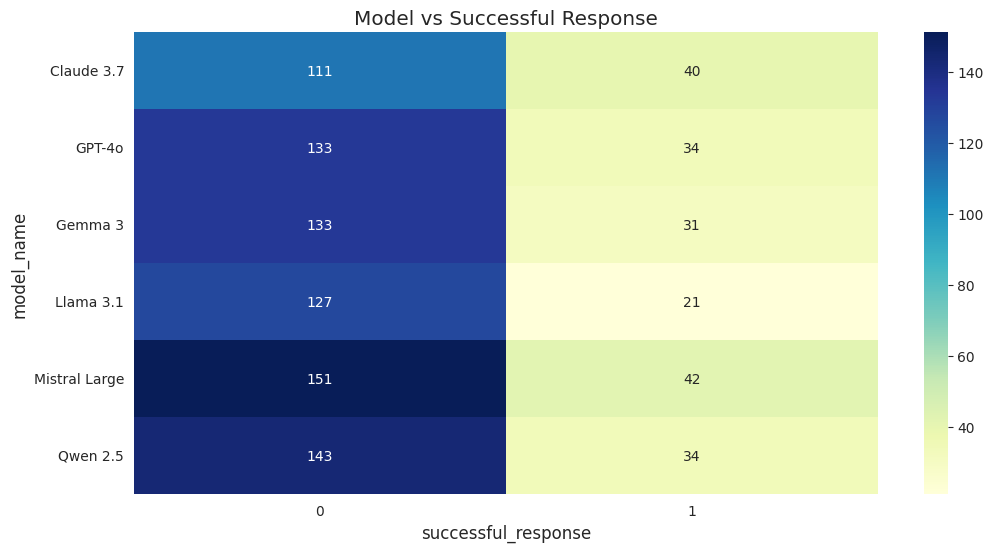

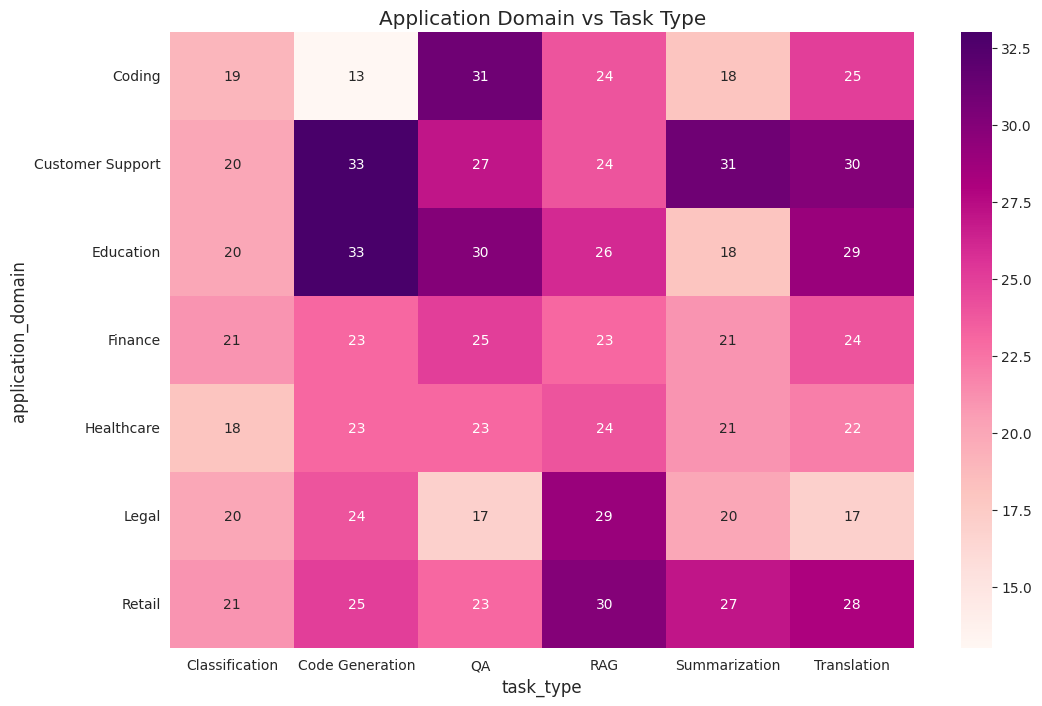

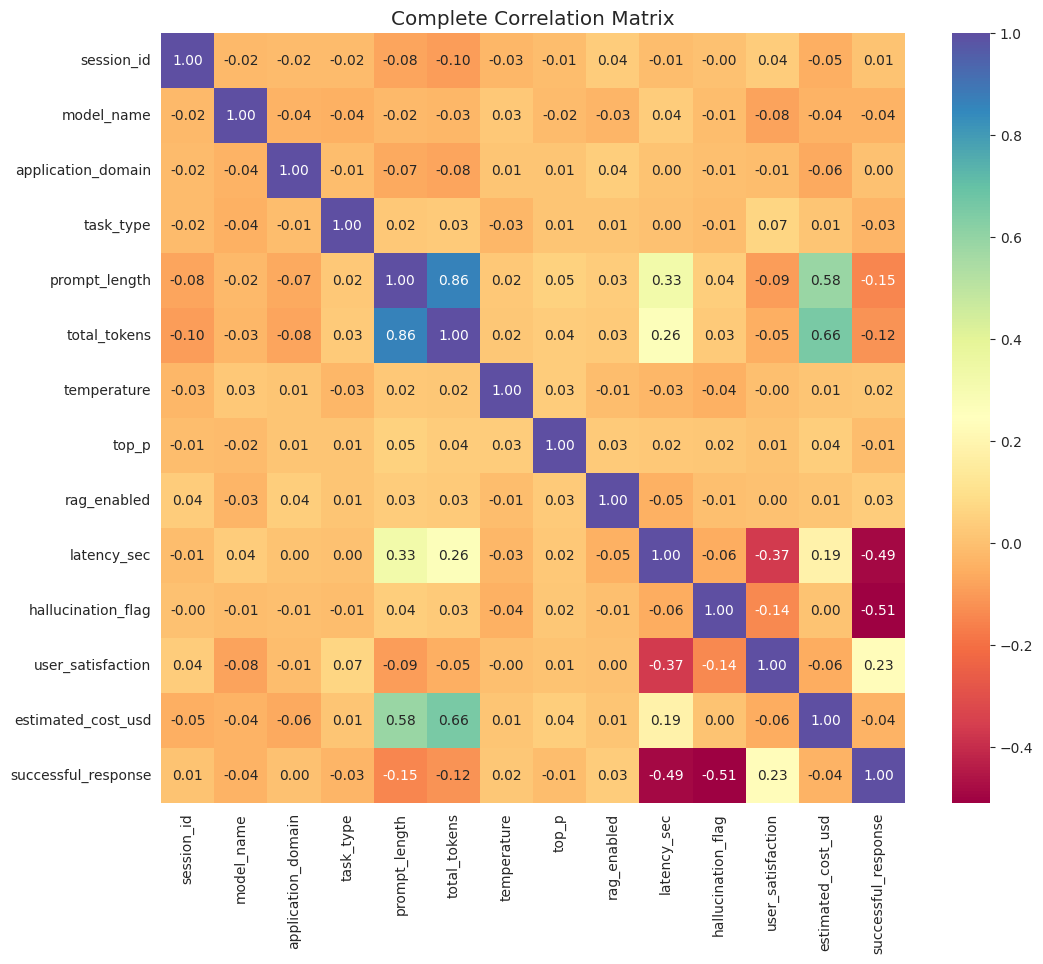

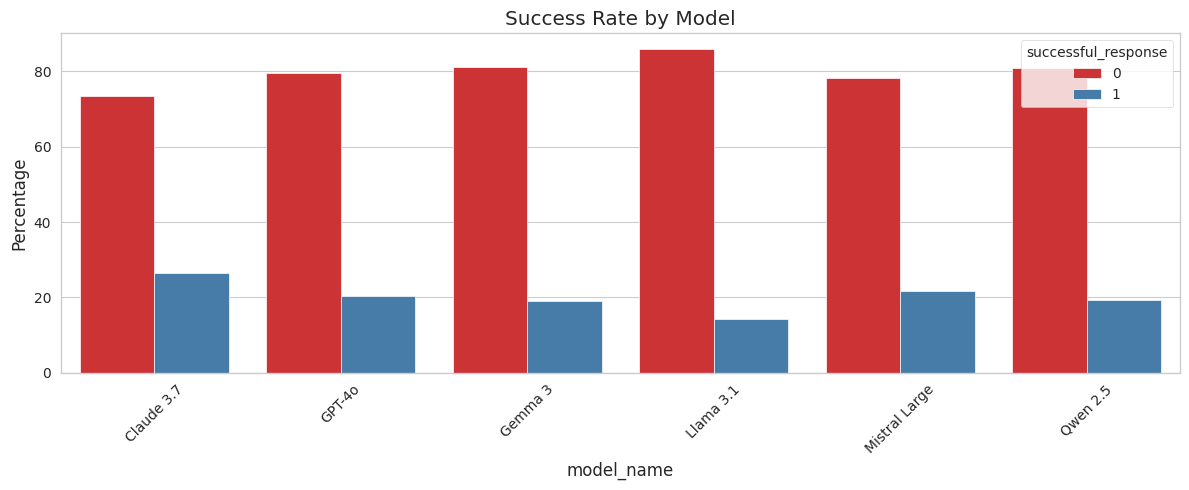

Average Metrics by Model
               latency_sec  estimated_cost_usd  user_satisfaction  \
model_name                                                          
Claude 3.7           5.230               0.020              4.470   
GPT-4o               5.380               0.018              4.377   
Gemma 3              5.126               0.017              4.341   
Llama 3.1            5.655               0.018              4.250   
Mistral Large        5.272               0.017              4.326   
Qwen 2.5             5.565               0.018              4.311   

               total_tokens  
model_name                   
Claude 3.7         1674.987  
GPT-4o             1684.132  
Gemma 3            1608.884  
Llama 3.1          1639.230  
Mistral Large      1561.850  
Qwen 2.5           1664.915  


Average Metrics by Application Domain
                    latency_sec  estimated_cost_usd  user_satisfaction
application_domain                                                    


In [13]:
# =============================================================================
# PART 3 : ADVANCED EDA & BUSINESS INSIGHTS
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.style.use("ggplot")
sns.set_style("whitegrid")

# =============================================================================
# 1. Average Latency by Application Domain
# =============================================================================

plt.figure(figsize=(12,5))

avg_latency = df.groupby("application_domain")["latency_sec"].mean().sort_values()

sns.barplot(
    x=avg_latency.index,
    y=avg_latency.values,
    palette="viridis"
)

plt.title("Average Latency by Application Domain")
plt.xlabel("Application Domain")
plt.ylabel("Average Latency (sec)")
plt.xticks(rotation=45)

for i, v in enumerate(avg_latency.values):
    plt.text(i, v, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# =============================================================================
# 2. Average Cost by Task Type
# =============================================================================

plt.figure(figsize=(12,5))

avg_cost = df.groupby("task_type")["estimated_cost_usd"].mean().sort_values()

sns.barplot(
    x=avg_cost.index,
    y=avg_cost.values,
    palette="magma"
)

plt.title("Average Cost by Task Type")
plt.xticks(rotation=45)

for i, v in enumerate(avg_cost.values):
    plt.text(i, v, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# =============================================================================
# 3. User Satisfaction by Model
# =============================================================================

plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="model_name",
    y="user_satisfaction",
    palette="Set3"
)

plt.xticks(rotation=45)
plt.title("User Satisfaction by Model")
plt.tight_layout()
plt.show()

# =============================================================================
# 4. Temperature Distribution by Model
# =============================================================================

plt.figure(figsize=(12,5))

sns.violinplot(
    data=df,
    x="model_name",
    y="temperature",
    palette="coolwarm"
)

plt.xticks(rotation=45)
plt.title("Temperature Distribution by Model")
plt.tight_layout()
plt.show()

# =============================================================================
# 5. Top-P Distribution by Model
# =============================================================================

plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="model_name",
    y="top_p",
    palette="Pastel2"
)

plt.xticks(rotation=45)
plt.title("Top-P Distribution by Model")
plt.tight_layout()
plt.show()

# =============================================================================
# 6. Prompt Length vs Satisfaction
# =============================================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="prompt_length",
    y="user_satisfaction",
    hue="hallucination_flag",
    palette="Set1",
    s=80
)

plt.title("Prompt Length vs User Satisfaction")
plt.show()

# =============================================================================
# 7. Token Usage vs Latency
# =============================================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="total_tokens",
    y="latency_sec",
    hue="rag_enabled",
    palette="Dark2",
    s=90
)

plt.title("Total Tokens vs Latency")
plt.show()

# =============================================================================
# 8. Average Cost by RAG
# =============================================================================

plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x="rag_enabled",
    y="estimated_cost_usd",
    estimator=np.mean,
    palette="Accent"
)

plt.title("Average Cost by RAG")
plt.show()

# =============================================================================
# 9. Average Satisfaction by Hallucination
# =============================================================================

plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x="hallucination_flag",
    y="user_satisfaction",
    estimator=np.mean,
    palette="Set2"
)

plt.title("Average Satisfaction by Hallucination")
plt.show()

# =============================================================================
# 10. Average Latency by Successful Response
# =============================================================================

plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x="successful_response",
    y="latency_sec",
    estimator=np.mean,
    palette="coolwarm"
)

plt.title("Latency by Successful Response")
plt.show()

# =============================================================================
# 11. Crosstab : Model vs Success
# =============================================================================

model_success = pd.crosstab(
    df["model_name"],
    df["successful_response"]
)

plt.figure(figsize=(12,6))

sns.heatmap(
    model_success,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("Model vs Successful Response")
plt.show()

# =============================================================================
# 12. Crosstab : Domain vs Task
# =============================================================================

domain_task = pd.crosstab(
    df["application_domain"],
    df["task_type"]
)

plt.figure(figsize=(12,8))

sns.heatmap(
    domain_task,
    annot=True,
    cmap="RdPu",
    fmt="d"
)

plt.title("Application Domain vs Task Type")
plt.show()

# =============================================================================
# 13. Correlation Heatmap (Encoded)
# =============================================================================

encoded = df.copy()

for col in encoded.select_dtypes(include="object").columns:
    encoded[col] = encoded[col].astype("category").cat.codes

plt.figure(figsize=(12,10))

sns.heatmap(
    encoded.corr(),
    cmap="Spectral",
    annot=True,
    fmt=".2f"
)

plt.title("Complete Correlation Matrix")
plt.show()

# =============================================================================
# 14. Success Rate by Model
# =============================================================================

success_rate = (
    df.groupby("model_name")["successful_response"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Percentage")
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=success_rate,
    x="model_name",
    y="Percentage",
    hue="successful_response",
    palette="Set1"
)

plt.xticks(rotation=45)
plt.title("Success Rate by Model")
plt.tight_layout()
plt.show()

# =============================================================================
# 15. Average Metrics by Model
# =============================================================================

summary = df.groupby("model_name")[[
    "latency_sec",
    "estimated_cost_usd",
    "user_satisfaction",
    "total_tokens"
]].mean()

print("="*70)
print("Average Metrics by Model")
print("="*70)
print(summary.round(3))

# =============================================================================
# 16. Average Metrics by Application Domain
# =============================================================================

domain_summary = df.groupby("application_domain")[[
    "latency_sec",
    "estimated_cost_usd",
    "user_satisfaction"
]].mean()

print("\n")
print("="*70)
print("Average Metrics by Application Domain")
print("="*70)
print(domain_summary.round(3))

# =============================================================================
# 17. Average Metrics by Task Type
# =============================================================================

task_summary = df.groupby("task_type")[[
    "latency_sec",
    "estimated_cost_usd",
    "user_satisfaction"
]].mean()

print("\n")
print("="*70)
print("Average Metrics by Task Type")
print("="*70)
print(task_summary.round(3))

print("\n")
print("="*80)
print("PART 3 COMPLETED SUCCESSFULLY")
print("="*80)

## Features Engineering

In [14]:
# =============================================================================
# PART 1 : PREPROCESSING (NO DATA LEAKAGE)
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# =============================================================================
# Visualization Libraries
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# Scikit Learn
# =============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# =============================================================================
# Make Copy
# =============================================================================

data = df.copy()

# =============================================================================
# Dataset Information
# =============================================================================

print("="*80)
print("DATASET SHAPE")
print("="*80)
print(data.shape)

print("\n")

print("="*80)
print("COLUMN NAMES")
print("="*80)
print(data.columns)

print("\n")

print("="*80)
print("DATA TYPES")
print("="*80)
print(data.dtypes)

# =============================================================================
# Remove Duplicate Rows
# =============================================================================

duplicates = data.duplicated().sum()

print("\nDuplicate Rows :", duplicates)

data.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates :", data.shape)

# =============================================================================
# Drop Session ID
# =============================================================================

if "session_id" in data.columns:
    data.drop(columns=["session_id"], inplace=True)

# =============================================================================
# Missing Values
# =============================================================================

print("\n")
print("="*80)
print("MISSING VALUES")
print("="*80)

print(data.isnull().sum())

# =============================================================================
# Fill Missing Values
# =============================================================================

numeric_columns = data.select_dtypes(include=np.number).columns

categorical_columns = data.select_dtypes(include="object").columns

for col in numeric_columns:
    data[col] = data[col].fillna(data[col].median())

for col in categorical_columns:
    data[col] = data[col].fillna(data[col].mode()[0])

# =============================================================================
# Target Column
# =============================================================================

TARGET = "successful_response"

X = data.drop(columns=[TARGET])

y = data[TARGET]

print("\n")
print("="*80)
print("TARGET COLUMN")
print("="*80)
print(y.value_counts())

# =============================================================================
# Train Test Split
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n")
print("="*80)
print("TRAIN TEST SPLIT")
print("="*80)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

# =============================================================================
# Encode Target
# =============================================================================

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)

y_test = target_encoder.transform(y_test)

print("\nTarget Classes")
print(target_encoder.classes_)

# =============================================================================
# Identify Columns
# =============================================================================

cat_cols = X_train.select_dtypes(include="object").columns.tolist()

num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("\n")

print("="*80)
print("CATEGORICAL COLUMNS")
print("="*80)

print(cat_cols)

print("\n")

print("="*80)
print("NUMERICAL COLUMNS")
print("="*80)

print(num_cols)

# =============================================================================
# Label Encoding (Training First -> No Leakage)
# =============================================================================

label_encoders = {}

for col in cat_cols:

    encoder = LabelEncoder()

    X_train[col] = encoder.fit_transform(
        X_train[col].astype(str)
    )

    X_test[col] = X_test[col].astype(str)

    unseen = set(X_test[col]) - set(encoder.classes_)

    if len(unseen) > 0:
        encoder.classes_ = np.append(
            encoder.classes_,
            list(unseen)
        )

    X_test[col] = encoder.transform(X_test[col])

    label_encoders[col] = encoder

# =============================================================================
# Feature Scaling
# =============================================================================

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

print("\n")
print("="*80)
print("PREPROCESSING COMPLETED")
print("="*80)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("\n")

print("X_train")
print(X_train.head())

print("\n")

print("X_test")
print(X_test.head())

print("\n")

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

print("\n")
print("="*80)
print("PART 1 COMPLETED SUCCESSFULLY")
print("="*80)

DATASET SHAPE
(1000, 14)


COLUMN NAMES
Index(['session_id', 'model_name', 'application_domain', 'task_type',
       'prompt_length', 'total_tokens', 'temperature', 'top_p', 'rag_enabled',
       'latency_sec', 'hallucination_flag', 'user_satisfaction',
       'estimated_cost_usd', 'successful_response'],
      dtype='object')


DATA TYPES
session_id               int64
model_name              object
application_domain      object
task_type               object
prompt_length            int64
total_tokens             int64
temperature            float64
top_p                  float64
rag_enabled              int64
latency_sec            float64
hallucination_flag       int64
user_satisfaction        int64
estimated_cost_usd     float64
successful_response      int64
dtype: object

Duplicate Rows : 0
Shape After Removing Duplicates : (1000, 14)


MISSING VALUES
model_name             0
application_domain     0
task_type              0
prompt_length          0
total_tokens           0
tem

In [15]:
# =============================================================================
# PART 2 : MACHINE LEARNING MODELS
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Try XGBoost
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

# =============================================================================
# MODELS
# =============================================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "AdaBoost":
        AdaBoostClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Naive Bayes":
        GaussianNB(),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

# =============================================================================
# TRAIN MODELS
# =============================================================================

trained_models = {}

predictions = {}

probabilities = {}

print("="*80)
print("TRAINING MODELS")
print("="*80)

for name, model in models.items():

    print(f"\nTraining : {name}")

    model.fit(X_train, y_train)

    trained_models[name] = model

    predictions[name] = model.predict(X_test)

    probabilities[name] = model.predict_proba(X_test)[:,1]

    print(f"{name} Training Completed")

print("\n")
print("="*80)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("="*80)

print("\nModels Trained:")

for model in trained_models.keys():
    print("✔", model)
    

TRAINING MODELS

Training : Logistic Regression
Logistic Regression Training Completed

Training : Decision Tree
Decision Tree Training Completed

Training : Random Forest
Random Forest Training Completed

Training : Extra Trees
Extra Trees Training Completed

Training : Gradient Boosting
Gradient Boosting Training Completed

Training : AdaBoost
AdaBoost Training Completed

Training : KNN
KNN Training Completed

Training : Naive Bayes
Naive Bayes Training Completed

Training : SVM
SVM Training Completed

Training : XGBoost
XGBoost Training Completed


ALL MODELS TRAINED SUCCESSFULLY

Models Trained:
✔ Logistic Regression
✔ Decision Tree
✔ Random Forest
✔ Extra Trees
✔ Gradient Boosting
✔ AdaBoost
✔ KNN
✔ Naive Bayes
✔ SVM
✔ XGBoost


MODEL PERFORMANCE

Logistic Regression
Accuracy  : 0.9950
Precision : 0.9756
Recall    : 1.0000
F1 Score  : 0.9877
ROC AUC   : 0.9995

Decision Tree
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC AUC   : 1.0000

Random Forest
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC AUC   : 1.0000

Extra Trees
Accuracy  : 0.9850
Precision : 0.9744
Recall    : 0.9500
F1 Score  : 0.9620
ROC AUC   : 0.9994

Gradient Boosting
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC AUC   : 1.0000

AdaBoost
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC AUC   : 1.0000

KNN
Accuracy  : 0.8950
Precision : 0.7714
Recall    : 0.6750
F1 Score  : 0.7200
ROC AUC   : 0.9085

Naive Bayes
Accuracy  : 0.7550
Precision : 0.4494
Recall    : 1.0000
F1 Score  : 0.6202
ROC AUC   : 0.9941

SVM
Accuracy  : 0.9950
Precision : 0.9756
Recall    : 1.0000
F1 Score  : 0.9877
ROC AUC   : 0.9998

XGBoost
Ac

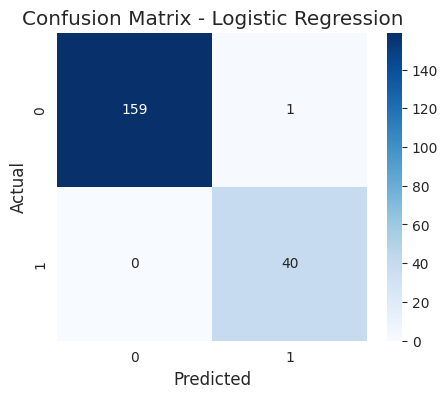

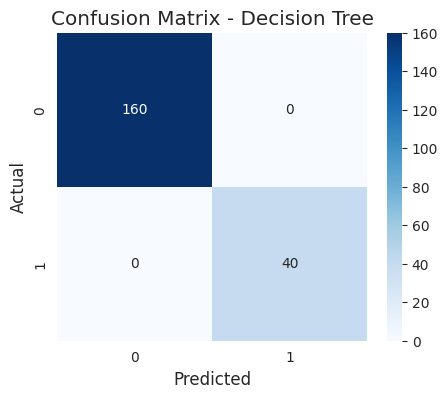

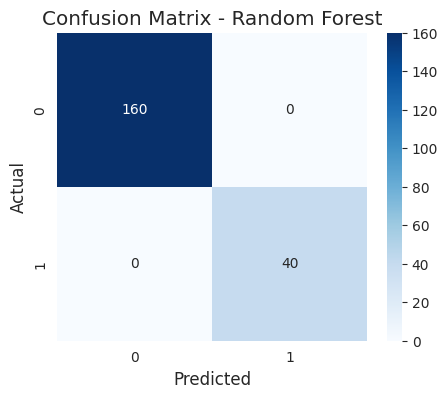

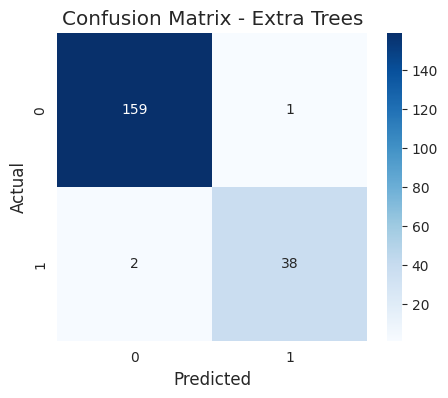

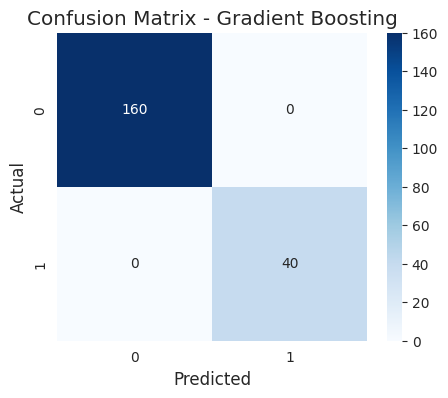

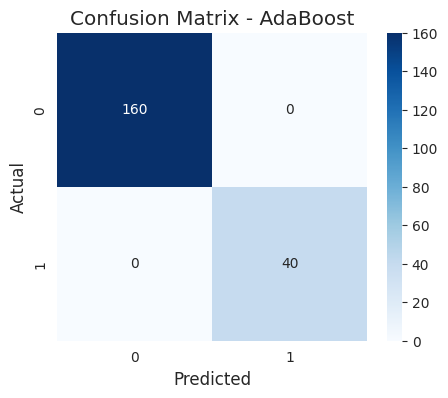

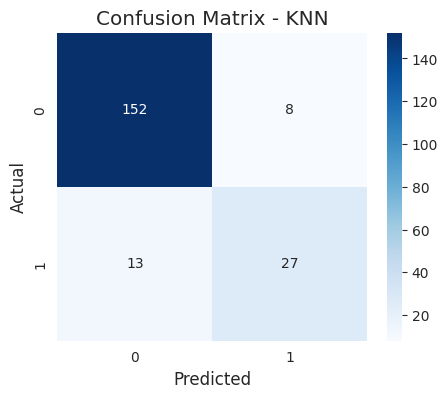

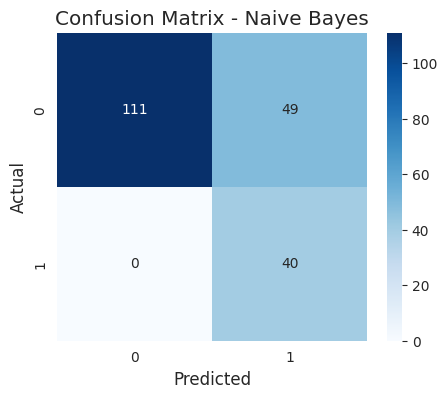

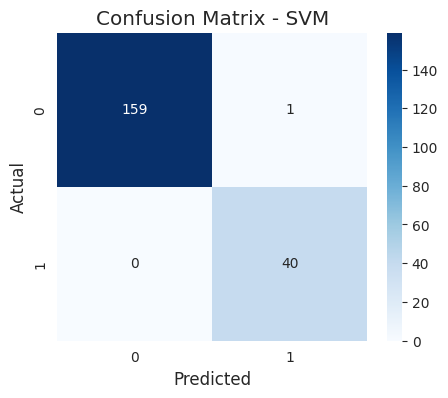

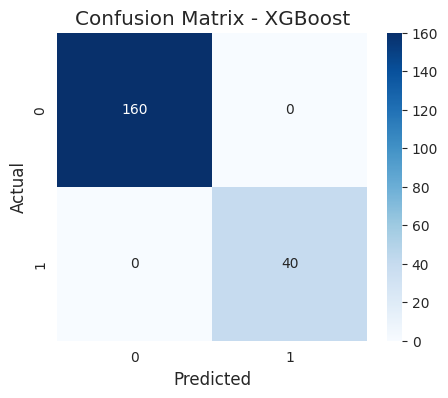

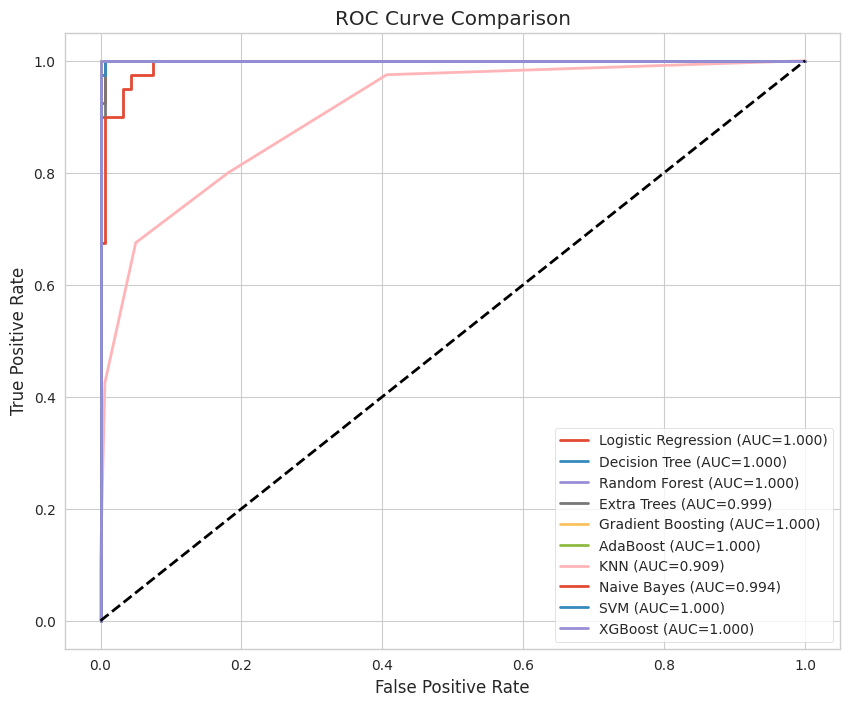

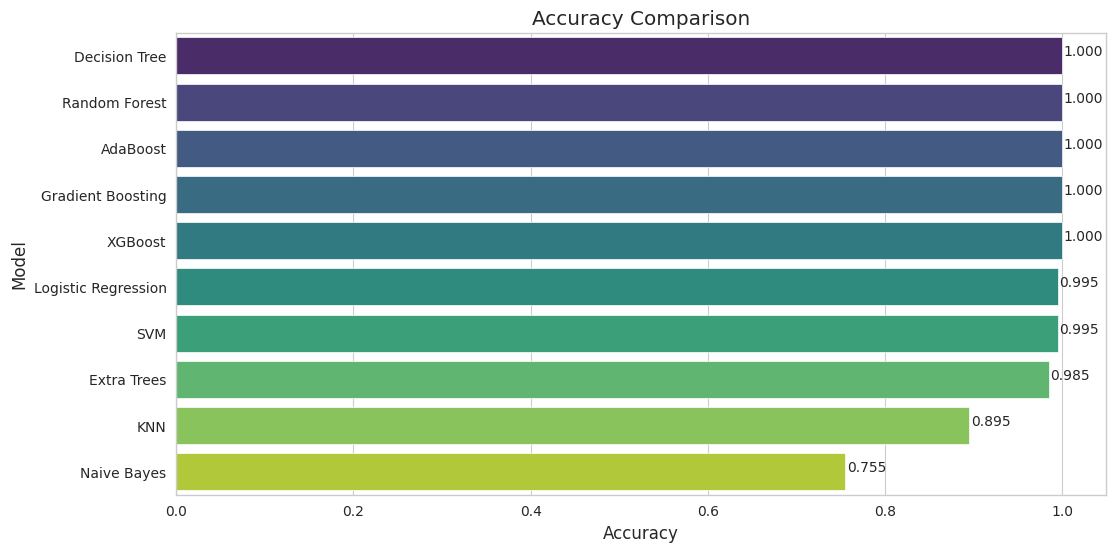

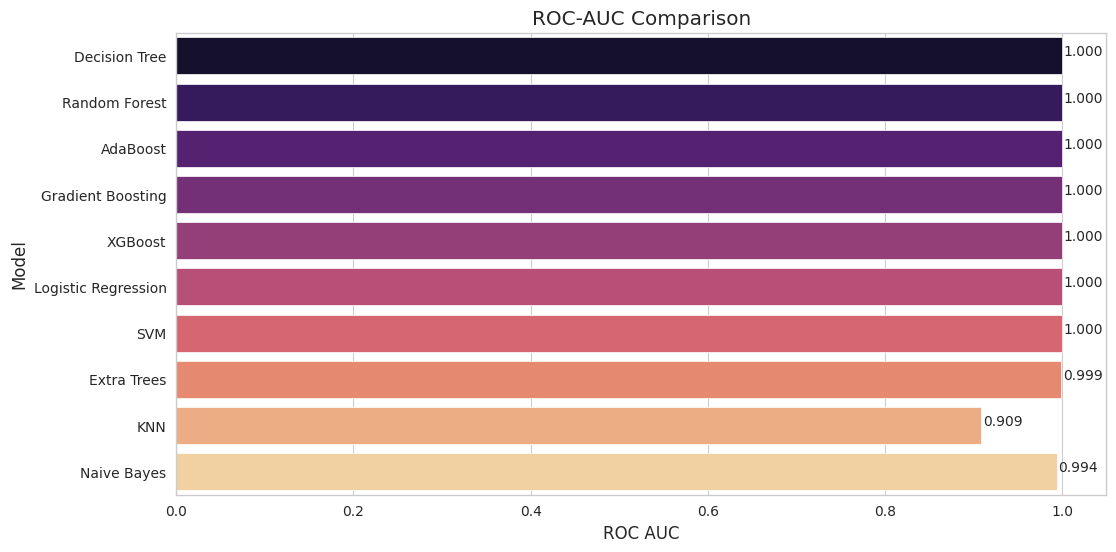



Evaluation Completed Successfully

Results saved as : Model_Comparison.csv


In [16]:
# =============================================================================
# PART 3 : MODEL EVALUATION
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# RESULTS
# =============================================================================

results = []

print("="*90)
print("MODEL PERFORMANCE")
print("="*90)

for name in trained_models.keys():

    y_pred = predictions[name]
    y_prob = probabilities[name]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

    print("\n" + "="*80)
    print(name)
    print("="*80)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {auc:.4f}")

# =============================================================================
# RESULTS TABLE
# =============================================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("\n")
print("="*90)
print("MODEL COMPARISON")
print("="*90)

print(results_df)

# =============================================================================
# BEST MODEL
# =============================================================================

best_model_name = results_df.iloc[0]["Model"]

print("\n")
print("="*90)
print("BEST MODEL")
print("="*90)

print("Best Model :", best_model_name)

# =============================================================================
# CLASSIFICATION REPORTS
# =============================================================================

for name in trained_models.keys():

    print("\n")
    print("="*90)
    print(f"Classification Report : {name}")
    print("="*90)

    print(
        classification_report(
            y_test,
            predictions[name],
            zero_division=0
        )
    )

# =============================================================================
# CONFUSION MATRICES
# =============================================================================

for name in trained_models.keys():

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

# =============================================================================
# ROC CURVE
# =============================================================================

plt.figure(figsize=(10,8))

for name in trained_models.keys():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities[name]
    )

    auc = roc_auc_score(
        y_test,
        probabilities[name]
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    "k--",
    linewidth=2
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

# =============================================================================
# ACCURACY BAR CHART
# =============================================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Accuracy Comparison")

for index, value in enumerate(results_df["Accuracy"]):
    plt.text(
        value + 0.002,
        index,
        f"{value:.3f}"
    )

plt.show()

# =============================================================================
# ROC AUC BAR CHART
# =============================================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="ROC AUC",
    y="Model",
    palette="magma"
)

plt.title("ROC-AUC Comparison")

for index, value in enumerate(results_df["ROC AUC"]):
    plt.text(
        value + 0.002,
        index,
        f"{value:.3f}"
    )

plt.show()

# =============================================================================
# SAVE RESULTS
# =============================================================================

results_df.to_csv(
    "Model_Comparison.csv",
    index=False
)

print("\n")
print("="*90)
print("Evaluation Completed Successfully")
print("="*90)

print("\nResults saved as : Model_Comparison.csv")

Random Forest Hyperparameter Tuning

Best Parameters

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15, 'bootstrap': False}

Accuracy : 1.0

ROC AUC : 1.0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       160
           1       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



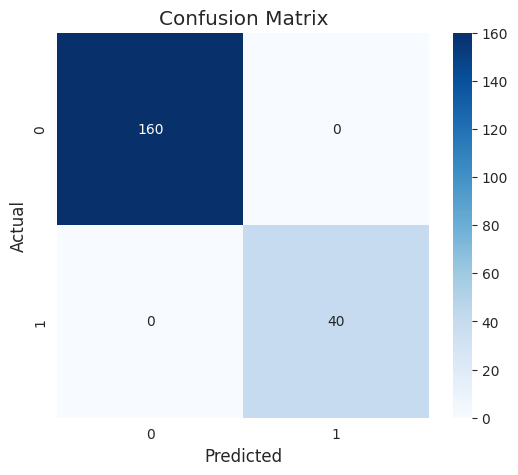

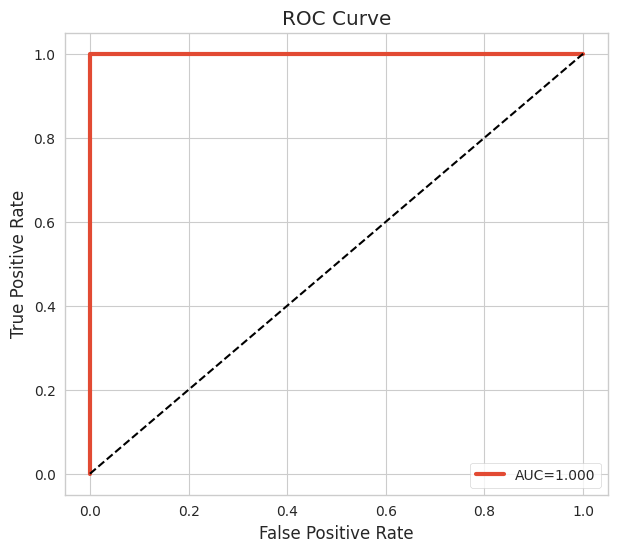


Top Important Features

               Feature  Importance
9   hallucination_flag    0.670198
8          latency_sec    0.329802
0           model_name    0.000000
1   application_domain    0.000000
3        prompt_length    0.000000
2            task_type    0.000000
4         total_tokens    0.000000
5          temperature    0.000000
7          rag_enabled    0.000000
6                top_p    0.000000
10   user_satisfaction    0.000000
11  estimated_cost_usd    0.000000


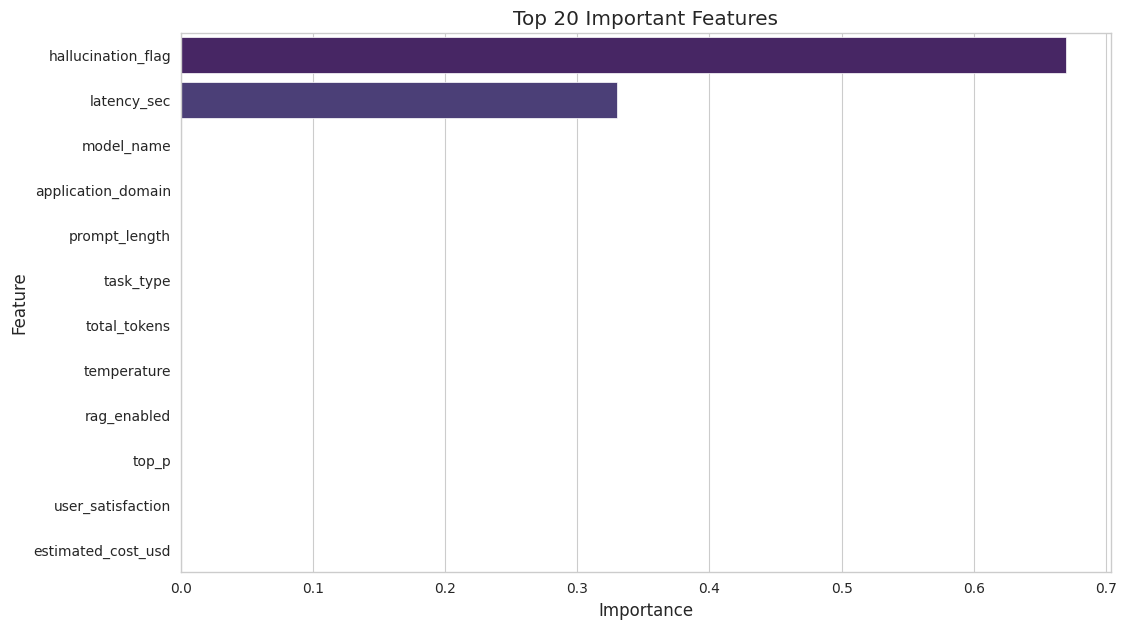


Model Saved Successfully
Feature Importance Saved
PART 4 COMPLETED


In [17]:
# =============================================================================
# PART 4 : HYPERPARAMETER TUNING + FEATURE IMPORTANCE + SAVE MODEL
# =============================================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# =============================================================================
# RANDOM FOREST HYPERPARAMETERS
# =============================================================================

param_grid = {

    "n_estimators":[100,200,300,400,500],

    "max_depth":[5,10,15,20,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4],

    "max_features":["sqrt","log2",None],

    "bootstrap":[True,False]

}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(

    estimator=rf,

    param_distributions=param_grid,

    n_iter=20,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1

)

print("="*80)
print("Random Forest Hyperparameter Tuning")
print("="*80)

random_search.fit(X_train, y_train)

# =============================================================================
# BEST MODEL
# =============================================================================

best_rf = random_search.best_estimator_

print("\nBest Parameters\n")
print(random_search.best_params_)

# =============================================================================
# PREDICTION
# =============================================================================

y_pred = best_rf.predict(X_test)

y_prob = best_rf.predict_proba(X_test)[:,1]

# =============================================================================
# METRICS
# =============================================================================

accuracy = accuracy_score(y_test,y_pred)

auc = roc_auc_score(y_test,y_prob)

print("\nAccuracy :",accuracy)

print("\nROC AUC :",auc)

print("\n")

print(classification_report(y_test,y_pred))

# =============================================================================
# CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =============================================================================
# ROC CURVE
# =============================================================================

fpr,tpr,_ = roc_curve(y_test,y_prob)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,

    tpr,

    linewidth=3,

    label=f"AUC={auc:.3f}"

)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# =============================================================================
# FEATURE IMPORTANCE
# =============================================================================

importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":best_rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print("\nTop Important Features\n")

print(importance.head(20))

plt.figure(figsize=(12,7))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 20 Important Features")

plt.show()

# =============================================================================
# SAVE MODEL
# =============================================================================

joblib.dump(best_rf,"best_random_forest_model.pkl")

print("\nModel Saved Successfully")

# =============================================================================
# SAVE FEATURE IMPORTANCE
# =============================================================================

importance.to_csv(

    "Feature_Importance.csv",

    index=False

)

print("Feature Importance Saved")

print("="*80)
print("PART 4 COMPLETED")
print("="*80)

## Thanks.......Please Upvote